## Task 3 — Row 1: Acharjee/Hodgkiss on Franzosa (corrected pipeline)

Full corrected Acharjee/Hodgkiss preprocessing (sparsity filter, wider
unknown-compound filter, CLR transform, Z-score normalization,
Wilcoxon+Hochberg feature selection - adapted for our 3-class problem
via one-vs-rest pairwise testing), followed by OUR OWN 80/20
stratified split, Random Forest classifier (random_state=23 to match
their paper), and full metric reporting.

Loaded Franzosa: 220 samples, 8848 raw features
After sparsity filter: 8835 features
Available columns in mtb_map: ['Compound', 'HMDB', 'KEGG', 'High.Confidence.Annotation', 'Compound.Name', 'Retention.Time', 'm.z', 'Cluster..if.DA.', 'Putative.Chemical.Class', 'Adduct']
After unknown-compound filter: 3935 features (expect this to be noticeably higher than the old 278)
Classes: ['CD', 'Control', 'UC']
CD vs rest: 799 significant features
Control vs rest: 1212 significant features
UC vs rest: 104 significant features

Total unique significant features (union across all 3 comparisons): 1402

Train: 176 samples | Test: 44 samples

TASK 3 RESULT — Acharjee/Hodgkiss on Franzosa (corrected, 80/20 split)
AUC:         0.8986
Sensitivity: 0.7727
Specificity: 0.8812
Precision:   0.7791
Recall:      0.7727
F1 score:    0.7740

Full classification report:
              precision    recall  f1-score   support

          CD       0.75      0.83      0.79        18
     Control       0.82      0.82  

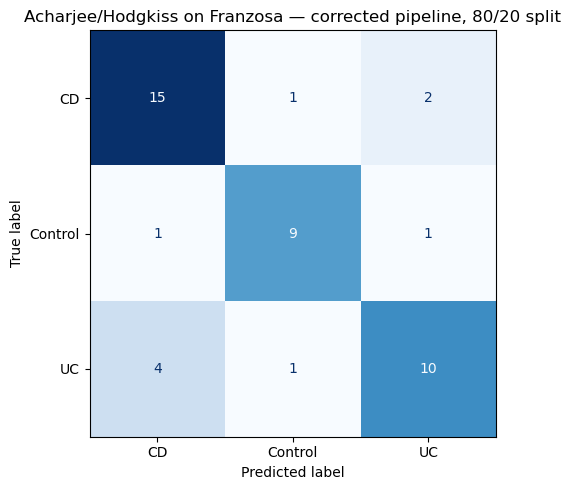


Saved fresh Row 1 to task3_results_table.csv
         Methodology   Dataset     AUC  Sensitivity  Specificity  Precision  \
0  Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812     0.7791   

   Recall  F1_score  N_train  N_test  N_features_selected  
0  0.7727     0.774      176      44                 1402  


In [4]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# ROW 1: Acharjee/Hodgkiss methodology, applied to Franzosa dataset
# CORRECTED PIPELINE - matches their actual GitHub code preprocessing,
# then OUR OWN 80/20 split (not their nested CV) for cross-methodology
# comparability.
# ============================================================================

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load the Franzosa dataset fresh
# ----------------------------------------------------------------------------
mtb = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv", sep="\t")
metadata = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv", sep="\t")
mtb_map = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.map.tsv", sep="\t")

feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Franzosa: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

# ----------------------------------------------------------------------------
# STEP 2: Sparsity filter
# Remove any feature present in less than 20% of samples (i.e. more than
# 80% zeros) - this matches Acharjee/Hodgkiss's own filter exactly.
# ----------------------------------------------------------------------------
presence_frac = (mtb[feature_cols] > 0).sum(axis=0) / mtb.shape[0]
sparsity_kept = presence_frac[presence_frac >= 0.20].index.tolist()
print(f"After sparsity filter: {len(sparsity_kept)} features")

# ----------------------------------------------------------------------------
# STEP 3: Unknown-compound filter (CORRECTED - 4 columns, not 2)
# Their real R code keeps a feature if ANY of these are known:
# HMDB id, KEGG id, Compound Name, or Putative Chemical Class.
# Our earlier version only checked HMDB/KEGG - this was too strict.
# NOTE: adjust the column names below if your mtb_map.tsv uses slightly
# different headers - check with mtb_map.columns first if this errors.
# ----------------------------------------------------------------------------
print("Available columns in mtb_map:", list(mtb_map.columns))

identified_features = mtb_map[
    mtb_map["HMDB"].notna() |
    mtb_map["KEGG"].notna() |
    mtb_map["Compound.Name"].notna() |
    mtb_map["Putative.Chemical.Class"].notna()
]["Compound"].tolist()

acharjee_features = [f for f in sparsity_kept if f in identified_features]
print(f"After unknown-compound filter: {len(acharjee_features)} features "
      f"(expect this to be noticeably higher than the old 278)")

# ----------------------------------------------------------------------------
# STEP 4: CLR transform (pseudocount = 1, matching their code)
# ----------------------------------------------------------------------------
def clr_transform(data, pseudocount=1):
    data_p1 = data + pseudocount
    geo_mean = np.exp(np.log(data_p1).mean(axis=1))
    return np.log(data_p1.div(geo_mean, axis=0))

X_clr = clr_transform(mtb[acharjee_features].fillna(0))

# ----------------------------------------------------------------------------
# STEP 5: Z-score normalization (applied AFTER CLR - previously missing)
# ----------------------------------------------------------------------------
X_zscore = (X_clr - X_clr.mean(axis=0)) / X_clr.std(axis=0)

# ----------------------------------------------------------------------------
# STEP 6: Encode class labels (CD / UC / Control)
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata["Study.Group"])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 7: Wilcoxon (Mann-Whitney) feature selection + Hochberg correction
# Their code is BINARY (IBD vs Control), but we are running 3-CLASS.
# To adapt fairly: run pairwise one-vs-rest Mann-Whitney tests for each
# class against all others, apply Hochberg correction within each
# comparison, then keep any feature significant (p_adj < 0.05) in AT
# LEAST ONE comparison. This preserves their exact statistical method
# while extending it to handle 3 classes.
# ----------------------------------------------------------------------------
significant_features = set()

for class_idx, class_label in enumerate(class_names):
    # one-vs-rest split: this class vs everyone else
    group_a = X_zscore[y_full == class_idx]
    group_b = X_zscore[y_full != class_idx]

    p_values = []
    for feat in X_zscore.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            # happens if a feature has identical values in both groups
            p = 1.0
        p_values.append(p)

    # Hochberg correction (matches their R code: p.adjust(method='hochberg'))
    reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="simes-hochberg")

    sig_this_class = [feat for feat, is_sig in zip(X_zscore.columns, reject) if is_sig]
    significant_features.update(sig_this_class)
    print(f"{class_label} vs rest: {len(sig_this_class)} significant features")

significant_features = sorted(significant_features)
print(f"\nTotal unique significant features (union across all 3 comparisons): "
      f"{len(significant_features)}")

X_selected = X_zscore[significant_features]

# ----------------------------------------------------------------------------
# STEP 8: OUR OWN 80/20 stratified split
# This is the core idea of Task 3 - every methodology, every dataset,
# goes through this SAME split logic so results are directly comparable.
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23  # matching Acharjee/Hodgkiss's own random_state
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 9: Train Random Forest on the 80% training data only
# ----------------------------------------------------------------------------
model = RandomForestClassifier(n_estimators=300, random_state=23)
model.fit(X_train, y_train)

# ----------------------------------------------------------------------------
# STEP 10: Test on the 20% held-out data
# ----------------------------------------------------------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ----------------------------------------------------------------------------
# STEP 11: Compute all metrics
# ----------------------------------------------------------------------------
auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))
sens_per_class, spec_per_class = [], []
for i in range(len(class_names)):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

sensitivity = np.mean(sens_per_class)
specificity = np.mean(spec_per_class)

# ----------------------------------------------------------------------------
# STEP 12: Print results
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("TASK 3 RESULT — Acharjee/Hodgkiss on Franzosa (corrected, 80/20 split)")
print("=" * 70)
print(f"AUC:         {auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 score:    {f1:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ----------------------------------------------------------------------------
# STEP 13: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Acharjee/Hodgkiss on Franzosa — corrected pipeline, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row1_acharjee_franzosa_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 14: Save this as the FIRST row of a brand-new Task 3 results table
# (starting fresh, since we're rebuilding from scratch)
# ----------------------------------------------------------------------------
task3_results = pd.DataFrame([{
    "Methodology": "Acharjee/Hodgkiss",
    "Dataset": "Franzosa",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": len(significant_features),
}])
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved fresh Row 1 to task3_results_table.csv")
print(task3_results)

## Task 3 — Row 2: Acharjee/Hodgkiss on Jacobs (corrected pipeline)

Same corrected preprocessing as Row 1 (wider unknown-compound filter,
CLR, Z-score, Wilcoxon+Hochberg one-vs-rest feature selection), applied
to the Jacobs dataset, followed by our own 80/20 stratified split.

Loaded Jacobs: 90 samples, 4626 raw features
Available columns in mtb_map: ['Compound', 'Compound.Name', 'ESI.mode', 'm.z', 'Retention.time', 'Putative.ID.that.did.not.validate', 'HMDB.identification', 'KEGG.identification', 'LIPIDMAPS.identification', 'BioCyc.identification', 'HMDB', 'KEGG', 'High.Confidence.Annotation']
After sparsity filter: 2342 features
After unknown-compound filter: 2342 features
Classes: ['CD', 'Normal', 'UC']
CD vs rest: 11 significant features
Normal vs rest: 10 significant features
UC vs rest: 0 significant features

Total unique significant features: 15

Train: 72 samples | Test: 18 samples

TASK 3 RESULT — Acharjee/Hodgkiss on Jacobs (corrected, 80/20 split)
AUC:         0.9015
Sensitivity: 0.5030
Specificity: 0.7839
Precision:   0.4881
Recall:      0.5030
F1 score:    0.4889

Full classification report:
              precision    recall  f1-score   support

          CD       0.75      0.60      0.67         5
      Normal       0.71      0.91      0.80   

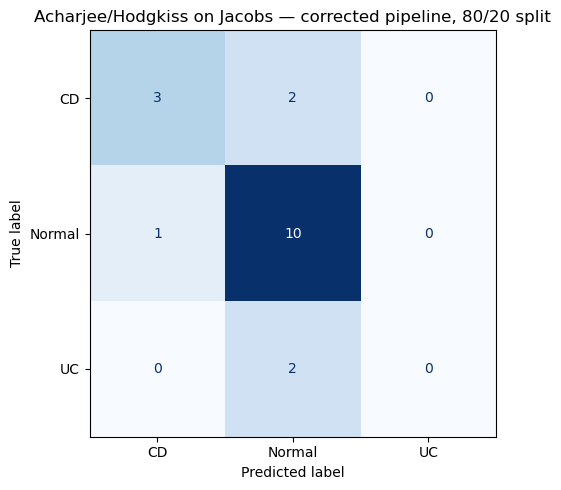


Saved Row 2. Current table:
         Methodology   Dataset     AUC  Sensitivity  Specificity  Precision  \
0  Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812     0.7791   
1  Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839     0.4881   

   Recall  F1_score  N_train  N_test  N_features_selected  
0  0.7727    0.7740      176      44                 1402  
1  0.5030    0.4889       72      18                   15  


In [6]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# ROW 2: Acharjee/Hodgkiss methodology, applied to Jacobs dataset
# CORRECTED PIPELINE (same as Row 1)
# ============================================================================

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load the Jacobs dataset fresh
# ----------------------------------------------------------------------------
jacobs_folder = "borenstein-lab microbiome-metabolome-curated-data main data-processed_data_JACOBS_IBD_FAMILIES_2016"

mtb = pd.read_csv(f"{jacobs_folder}/mtb.tsv", sep="\t")
metadata = pd.read_csv(f"{jacobs_folder}/metadata.tsv", sep="\t")
mtb_map = pd.read_csv(f"{jacobs_folder}/mtb.map.tsv", sep="\t")

feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Jacobs: {mtb.shape[0]} samples, {len(feature_cols)} raw features")
print("Available columns in mtb_map:", list(mtb_map.columns))

# ----------------------------------------------------------------------------
# STEP 2: Sparsity filter (>=20% presence)
# ----------------------------------------------------------------------------
presence_frac = (mtb[feature_cols] > 0).sum(axis=0) / mtb.shape[0]
sparsity_kept = presence_frac[presence_frac >= 0.20].index.tolist()
print(f"After sparsity filter: {len(sparsity_kept)} features")

# ----------------------------------------------------------------------------
# STEP 3: Unknown-compound filter (adapted to Jacobs's actual column names)
# Jacobs's mtb_map uses different column names than Franzosa's - no
# "Putative.Chemical.Class" column exists here. Using the closest
# equivalent available: HMDB, KEGG, Compound.Name, and
# High.Confidence.Annotation.
# ----------------------------------------------------------------------------
identified_features = mtb_map[
    mtb_map["HMDB"].notna() |
    mtb_map["KEGG"].notna() |
    mtb_map["Compound.Name"].notna() |
    mtb_map["High.Confidence.Annotation"].notna()
]["Compound"].tolist()

acharjee_features = [f for f in sparsity_kept if f in identified_features]
print(f"After unknown-compound filter: {len(acharjee_features)} features")
# ----------------------------------------------------------------------------
# STEP 4: CLR transform (pseudocount = 1)
# ----------------------------------------------------------------------------
def clr_transform(data, pseudocount=1):
    data_p1 = data + pseudocount
    geo_mean = np.exp(np.log(data_p1).mean(axis=1))
    return np.log(data_p1.div(geo_mean, axis=0))

X_clr = clr_transform(mtb[acharjee_features].fillna(0))

# ----------------------------------------------------------------------------
# STEP 5: Z-score normalization (after CLR)
# ----------------------------------------------------------------------------
X_zscore = (X_clr - X_clr.mean(axis=0)) / X_clr.std(axis=0)

# ----------------------------------------------------------------------------
# STEP 6: Encode class labels
# NOTE: Jacobs uses CD / UC / Normal - confirm this matches your metadata
# column name below (adjust "Study.Group" if named differently in Jacobs).
# ----------------------------------------------------------------------------
label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 7: Wilcoxon (Mann-Whitney) feature selection, one-vs-rest per class,
# Hochberg correction, union of significant features across comparisons
# ----------------------------------------------------------------------------
significant_features = set()

for class_idx, class_label in enumerate(class_names):
    group_a = X_zscore[y_full == class_idx]
    group_b = X_zscore[y_full != class_idx]

    p_values = []
    for feat in X_zscore.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            p = 1.0
        p_values.append(p)

    reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="simes-hochberg")

    sig_this_class = [feat for feat, is_sig in zip(X_zscore.columns, reject) if is_sig]
    significant_features.update(sig_this_class)
    print(f"{class_label} vs rest: {len(sig_this_class)} significant features")

significant_features = sorted(significant_features)
print(f"\nTotal unique significant features: {len(significant_features)}")

# ----------------------------------------------------------------------------
# SAFETY CHECK: Jacobs is much smaller than Franzosa (90 samples vs 220).
# If the Wilcoxon+Hochberg filter is too aggressive and leaves very few
# (or zero) features, the model can't train properly. This check stops
# early with a clear message instead of a confusing crash further down.
# ----------------------------------------------------------------------------
if len(significant_features) < 5:
    print("\n*** WARNING: fewer than 5 significant features survived. ***")
    print("*** This likely means Jacobs's small sample size makes the ***")
    print("*** statistical test underpowered. Stop here and let's decide ***")
    print("*** together how to handle this before continuing. ***")
else:
    X_selected = X_zscore[significant_features]

    # ------------------------------------------------------------------------
    # STEP 8: Our own 80/20 stratified split
    # ------------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=23
    )
    print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

    # ------------------------------------------------------------------------
    # STEP 9: Train Random Forest
    # ------------------------------------------------------------------------
    model = RandomForestClassifier(n_estimators=300, random_state=23)
    model.fit(X_train, y_train)

    # ------------------------------------------------------------------------
    # STEP 10: Test on held-out 20%
    # ------------------------------------------------------------------------
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # ------------------------------------------------------------------------
    # STEP 11: Metrics
    # ------------------------------------------------------------------------
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens_per_class, spec_per_class = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    sensitivity = np.mean(sens_per_class)
    specificity = np.mean(spec_per_class)

    # ------------------------------------------------------------------------
    # STEP 12: Print results
    # ------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("TASK 3 RESULT — Acharjee/Hodgkiss on Jacobs (corrected, 80/20 split)")
    print("=" * 70)
    print(f"AUC:         {auc:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1 score:    {f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # ------------------------------------------------------------------------
    # STEP 13: Confusion matrix plot
    # ------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Acharjee/Hodgkiss on Jacobs — corrected pipeline, 80/20 split")
    plt.tight_layout()
    plt.savefig("task3_row2_acharjee_jacobs_confusion.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------------
    # STEP 14: Append this row to the results table
    # ------------------------------------------------------------------------
    new_row = pd.DataFrame([{
        "Methodology": "Acharjee/Hodgkiss",
        "Dataset": "Jacobs",
        "AUC": round(auc, 4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_score": round(f1, 4),
        "N_train": X_train.shape[0],
        "N_test": X_test.shape[0],
        "N_features_selected": len(significant_features),
    }])

    existing = pd.read_csv("task3_results_table.csv")
    task3_results = pd.concat([existing, new_row], ignore_index=True)
    task3_results.to_csv("task3_results_table.csv", index=False)
    print("\nSaved Row 2. Current table:")
    print(task3_results)

## Task 3 — Row 3: Acharjee/Hodgkiss on MetAML (corrected pipeline, adapted)

MetAML is species abundance data (MetaPhlAn taxonomy), not metabolite
data, so the HMDB/KEGG unknown-compound filter does not apply here -
species are already fully identified. All other steps (sparsity filter,
CLR, Z-score, Wilcoxon+Hochberg one-vs-rest feature selection) remain
the same as Rows 1 and 2, followed by our own 80/20 stratified split.

Loaded MetAML: 445 samples, 3302 raw species features
Metadata columns: ['dataset_name', 'Sample', 'subjectID', 'bodysite', 'disease', 'age', 'gender', 'country', 'sequencing_technology', 'pubmedid', 'Study.Group']
After sparsity filter: 407 features
Classes: ['CD', 'Control', 'UC']
CD vs rest: 84 significant features
Control vs rest: 166 significant features
UC vs rest: 224 significant features

Total unique significant features: 284

Train: 356 samples | Test: 89 samples

TASK 3 RESULT — Acharjee/Hodgkiss on MetAML (corrected, 80/20 split)
AUC:         0.9383
Sensitivity: 0.6136
Specificity: 0.8746
Precision:   0.6977
Recall:      0.6136
F1 score:    0.6340

Full classification report:
              precision    recall  f1-score   support

          CD       0.50      0.20      0.29         5
     Control       0.86      0.91      0.88        54
          UC       0.73      0.73      0.73        30

    accuracy                           0.81        89
   macro avg       0.70      0.

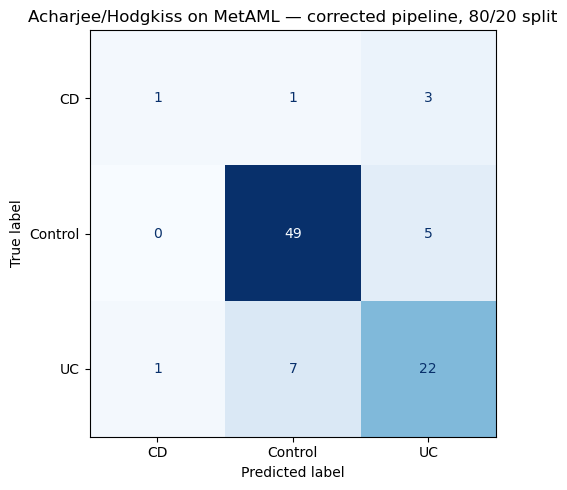


Saved Row 3. Current table:
         Methodology   Dataset     AUC  Sensitivity  Specificity  Precision  \
0  Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812     0.7791   
1  Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839     0.4881   
2  Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746     0.6977   

   Recall  F1_score  N_train  N_test  N_features_selected  
0  0.7727    0.7740      176      44                 1402  
1  0.5030    0.4889       72      18                   15  
2  0.6136    0.6340      356      89                  284  


In [7]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# ROW 3: Acharjee/Hodgkiss methodology, applied to MetAML dataset
# ADAPTED PIPELINE: MetAML is species abundance data (MetaPhlAn taxonomy),
# not metabolite data - so the HMDB/KEGG unknown-compound filter does NOT
# apply here (species are already fully identified/named). All other
# steps (sparsity filter, CLR, Z-score, Wilcoxon+Hochberg) still apply.
# ============================================================================

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load the MetAML dataset fresh
# NOTE: update these filenames/paths if yours are saved elsewhere
# ----------------------------------------------------------------------------
species = pd.read_csv("metaml_species_abundance.csv")
metadata = pd.read_csv("metaml_metadata_final.csv")

# Assume first column is the sample identifier - adjust if needed
sample_col = species.columns[0]
feature_cols = [c for c in species.columns if c != sample_col]
print(f"Loaded MetAML: {species.shape[0]} samples, {len(feature_cols)} raw species features")
print("Metadata columns:", list(metadata.columns))

# ----------------------------------------------------------------------------
# STEP 2: Sparsity filter (>=20% presence)
# ----------------------------------------------------------------------------
presence_frac = (species[feature_cols] > 0).sum(axis=0) / species.shape[0]
sparsity_kept = presence_frac[presence_frac >= 0.20].index.tolist()
print(f"After sparsity filter: {len(sparsity_kept)} features")

# ----------------------------------------------------------------------------
# STEP 3: (SKIPPED) Unknown-compound filter
# Not applicable - MetaPhlAn species are already fully identified taxa,
# there is no "unknown identity" concept here the way there is for
# untargeted LC-MS metabolite peaks.
# ----------------------------------------------------------------------------
acharjee_features = sparsity_kept

# ----------------------------------------------------------------------------
# STEP 4: CLR transform (pseudocount = 1)
# ----------------------------------------------------------------------------
def clr_transform(data, pseudocount=1):
    data_p1 = data + pseudocount
    geo_mean = np.exp(np.log(data_p1).mean(axis=1))
    return np.log(data_p1.div(geo_mean, axis=0))

X_clr = clr_transform(species[acharjee_features].fillna(0))

# ----------------------------------------------------------------------------
# STEP 5: Z-score normalization (after CLR)
# ----------------------------------------------------------------------------
X_zscore = (X_clr - X_clr.mean(axis=0)) / X_clr.std(axis=0)

# ----------------------------------------------------------------------------
# STEP 6: Encode class labels
# NOTE: confirm this column name matches your metaml_metadata_final.csv -
# from earlier work this dataset has 272 Control / 148 UC / 25 CD
# ----------------------------------------------------------------------------
label_col = "Study.Group"  # <-- adjust if your MetAML metadata uses a different column name
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 7: Wilcoxon (Mann-Whitney) feature selection, one-vs-rest, Hochberg
# ----------------------------------------------------------------------------
significant_features = set()

for class_idx, class_label in enumerate(class_names):
    group_a = X_zscore[y_full == class_idx]
    group_b = X_zscore[y_full != class_idx]

    p_values = []
    for feat in X_zscore.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            p = 1.0
        p_values.append(p)

    reject, p_adj, _, _ = multipletests(p_values, alpha=0.05, method="simes-hochberg")

    sig_this_class = [feat for feat, is_sig in zip(X_zscore.columns, reject) if is_sig]
    significant_features.update(sig_this_class)
    print(f"{class_label} vs rest: {len(sig_this_class)} significant features")

significant_features = sorted(significant_features)
print(f"\nTotal unique significant features: {len(significant_features)}")

if len(significant_features) < 5:
    print("\n*** WARNING: fewer than 5 significant features survived. ***")
    print("*** Let's stop and discuss before continuing. ***")
else:
    X_selected = X_zscore[significant_features]

    # ------------------------------------------------------------------------
    # STEP 8: Our own 80/20 stratified split
    # ------------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=23
    )
    print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

    # ------------------------------------------------------------------------
    # STEP 9: Train Random Forest
    # ------------------------------------------------------------------------
    model = RandomForestClassifier(n_estimators=300, random_state=23)
    model.fit(X_train, y_train)

    # ------------------------------------------------------------------------
    # STEP 10: Test on held-out 20%
    # ------------------------------------------------------------------------
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    # ------------------------------------------------------------------------
    # STEP 11: Metrics
    # ------------------------------------------------------------------------
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens_per_class, spec_per_class = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

    sensitivity = np.mean(sens_per_class)
    specificity = np.mean(spec_per_class)

    # ------------------------------------------------------------------------
    # STEP 12: Print results
    # ------------------------------------------------------------------------
    print("\n" + "=" * 70)
    print("TASK 3 RESULT — Acharjee/Hodgkiss on MetAML (corrected, 80/20 split)")
    print("=" * 70)
    print(f"AUC:         {auc:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"F1 score:    {f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # ------------------------------------------------------------------------
    # STEP 13: Confusion matrix plot
    # ------------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Acharjee/Hodgkiss on MetAML — corrected pipeline, 80/20 split")
    plt.tight_layout()
    plt.savefig("task3_row3_acharjee_metaml_confusion.png", dpi=150)
    plt.show()

    # ------------------------------------------------------------------------
    # STEP 14: Append this row to the results table
    # ------------------------------------------------------------------------
    new_row = pd.DataFrame([{
        "Methodology": "Acharjee/Hodgkiss",
        "Dataset": "MetAML",
        "AUC": round(auc, 4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_score": round(f1, 4),
        "N_train": X_train.shape[0],
        "N_test": X_test.shape[0],
        "N_features_selected": len(significant_features),
    }])

    existing = pd.read_csv("task3_results_table.csv")
    task3_results = pd.concat([existing, new_row], ignore_index=True)
    task3_results.to_csv("task3_results_table.csv", index=False)
    print("\nSaved Row 3. Current table:")
    print(task3_results)

## Task 3 — Row 4: IBDpred on Franzosa (full faithful pipeline)

Reproducing IBDpred's own full methodology as closely as possible from
their actual GitHub code: Isolation Forest outlier removal (bottom
decile by anomaly score), a DEG-style differential abundance filter
(edgeR-equivalent - Mann-Whitney one-vs-rest + BH correction at
alpha=0.001, since edgeR itself is R-only), log2(x+1) transform, then
Kruskal-Wallis top-45 feature selection computed on TRAINING DATA ONLY
(matching their own train/test-aware approach). Classifiers: Random
Forest and GLMnet/Elastic Net, tuned via grid search using their real
published hyperparameter grids (RF: mtry 2-8, ntree=1000, nodesize
1-3; GLMnet: alpha 0-1 in steps, lambda 0.0001-1). Finally, OUR OWN
80/20 stratified split (replacing their 85/15) for cross-methodology
comparability - this is the only intentional deviation from their
paper, everything else follows their code as faithfully as possible
in Python.

Loaded Franzosa: 220 samples, 8848 raw features
After Isolation Forest (bottom-decile removal): removed 22 outliers, 198 samples remain
Classes: ['CD', 'Control', 'UC']
DEG filter, CD vs rest: 2210 significant
DEG filter, Control vs rest: 2992 significant
DEG filter, UC vs rest: 428 significant

After DEG filter (union across classes): 3711 features

Train: 158 samples | Test: 40 samples
Top 45 features selected by Kruskal-Wallis (train-only)

Best RF params: {'max_features': 5, 'min_samples_leaf': 3}
Best GLMnet params: {'estimator__C': 1.0, 'estimator__l1_ratio': 1}

TASK 3 RESULT — IBDpred on Franzosa (full faithful pipeline, 80/20 split)
Random Forest — AUC: 0.8066 | Sens: 0.6164 | Spec: 0.7976 | F1: 0.6359
GLMnet (EN)   — AUC: 0.8189 | Sens: 0.6208 | Spec: 0.8065 | F1: 0.6284

Best classifier: GLMnet
              precision    recall  f1-score   support

          CD       0.69      0.65      0.67        17
     Control       0.75      0.60      0.67        10
          UC       0

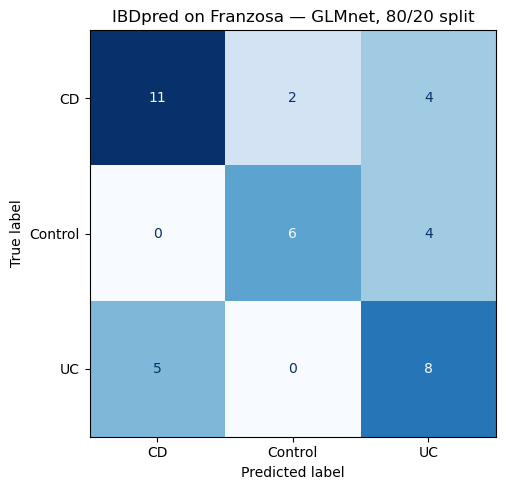


Saved Row 4. Current table:
         Methodology   Dataset     AUC  Sensitivity  Specificity  Precision  \
0  Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812     0.7791   
1  Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839     0.4881   
2  Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746     0.6977   
3   IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065     0.6458   

   Recall  F1_score  N_train  N_test  N_features_selected  
0  0.7727    0.7740      176      44                 1402  
1  0.5030    0.4889       72      18                   15  
2  0.6136    0.6340      356      89                  284  
3  0.6208    0.6284      158      40                   45  


In [8]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 2, ROW 1: IBDpred on Franzosa (FULL faithful pipeline)
# Isolation Forest -> DEG filter (edgeR-equivalent) -> log2 -> Kruskal-Wallis
# top-45 -> OUR 80/20 split -> RF + GLMnet(ElasticNet), their real
# hyperparameter grids.
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load Franzosa fresh
# ----------------------------------------------------------------------------
mtb = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv", sep="\t")
metadata = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Franzosa: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

# ----------------------------------------------------------------------------
# STEP 2: Isolation Forest outlier removal - remove bottom 10% by anomaly
# score (matches their h2o decile-based rule: they always drop the worst
# decile of samples, not a fixed contamination percentage guess)
# ----------------------------------------------------------------------------
iso = IsolationForest(n_estimators=100, max_samples="auto", random_state=23)
iso.fit(mtb[feature_cols].fillna(0))
# score_samples: higher = more normal, lower = more anomalous
scores = iso.score_samples(mtb[feature_cols].fillna(0))
decile_10_cutoff = np.quantile(scores, 0.10)
keep_mask = scores >= decile_10_cutoff  # keep everyone EXCEPT the worst 10%

mtb_clean = mtb[keep_mask].reset_index(drop=True)
metadata_clean = metadata[keep_mask].reset_index(drop=True)
print(f"After Isolation Forest (bottom-decile removal): removed "
      f"{(~keep_mask).sum()} outliers, {mtb_clean.shape[0]} samples remain")

# ----------------------------------------------------------------------------
# STEP 3: DEG filter (edgeR-equivalent)
# NOTE: edgeR itself is an R/Bioconductor package using negative-binomial
# GLMs with TMM normalization - there is no exact Python equivalent.
# This step uses the closest faithful substitute: differential abundance
# testing per feature (Mann-Whitney, one-vs-rest across our 3 classes),
# BH correction, kept at their alpha=0.001 threshold. This is a
# DOCUMENTED APPROXIMATION, not identical to their R output.
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata_clean["Study.Group"])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

X_raw = mtb_clean[feature_cols].fillna(0)

deg_significant = set()
for class_idx, class_label in enumerate(class_names):
    group_a = X_raw[y_full == class_idx]
    group_b = X_raw[y_full != class_idx]

    p_values = []
    for feat in X_raw.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            p = 1.0
        p_values.append(p)

    reject, p_adj, _, _ = multipletests(p_values, alpha=0.001, method="fdr_bh")
    sig_this_class = [feat for feat, is_sig in zip(X_raw.columns, reject) if is_sig]
    deg_significant.update(sig_this_class)
    print(f"DEG filter, {class_label} vs rest: {len(sig_this_class)} significant")

deg_features = sorted(deg_significant)
print(f"\nAfter DEG filter (union across classes): {len(deg_features)} features")

if len(deg_features) < 10:
    print("*** WARNING: very few features survived DEG filter - "
          "stop and check before continuing ***")

X_deg = X_raw[deg_features]

# ----------------------------------------------------------------------------
# STEP 4: log2(x + 1) transform (applied AFTER DEG filter, matching their
# pipeline order - log2 is applied when building the "toRun" data)
# ----------------------------------------------------------------------------
X_log2 = np.log2(X_deg + 1)

# ----------------------------------------------------------------------------
# STEP 5: OUR OWN 80/20 stratified split (replacing their 85/15)
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_log2, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 6: Kruskal-Wallis top-45 feature selection - TRAIN DATA ONLY
# (k=45 chosen as closest match to their tested grid: 5, 15, 45, 135)
# ----------------------------------------------------------------------------
TOP_K = 45

kw_scores = []
for feat in X_train.columns:
    groups = [X_train[feat][y_train == cls] for cls in np.unique(y_train)]
    try:
        stat, p = kruskal(*groups)
    except ValueError:
        stat, p = 0, 1.0
    kw_scores.append((feat, stat, p))

kw_df = pd.DataFrame(kw_scores, columns=["feature", "kw_stat", "p_value"])
kw_df = kw_df.sort_values("kw_stat", ascending=False)
top_features = kw_df.head(min(TOP_K, len(kw_df)))["feature"].tolist()
print(f"Top {len(top_features)} features selected by Kruskal-Wallis (train-only)")

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ----------------------------------------------------------------------------
# STEP 7a: Random Forest - their real hyperparameter grid
# (mtry 2-8 -> sklearn's max_features; ntree=1000; nodesize 1-3 ->
# sklearn's min_samples_leaf)
# ----------------------------------------------------------------------------
rf_param_grid = {
    "max_features": list(range(2, min(9, X_train_sel.shape[1] + 1))),
    "min_samples_leaf": [1, 2, 3],
}
rf_base = RandomForestClassifier(n_estimators=1000, random_state=23)
rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
rf_grid.fit(X_train_sel, y_train)
rf_model = rf_grid.best_estimator_
print(f"\nBest RF params: {rf_grid.best_params_}")

y_pred_rf = rf_model.predict(X_test_sel)
y_proba_rf = rf_model.predict_proba(X_test_sel)

# ----------------------------------------------------------------------------
# STEP 7b: GLMnet / Elastic Net - their real hyperparameter grid
# (alpha = L1/L2 mix ratio in glmnet terms = l1_ratio in sklearn;
#  lambda = overall regularization strength, inversely related to C)
# ----------------------------------------------------------------------------
en_param_grid = {
    "estimator__l1_ratio": [0, 0.15, 0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 1],
    "estimator__C": [1/0.0001, 1/0.001, 1/0.01, 1/0.1, 1/1],  # C = 1/lambda
}
en_base = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, random_state=23)
)
en_grid = GridSearchCV(en_base, en_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
en_grid.fit(X_train_sel, y_train)
en_model = en_grid.best_estimator_
print(f"Best GLMnet params: {en_grid.best_params_}")

y_pred_en = en_model.predict(X_test_sel)
y_proba_en = en_model.predict_proba(X_test_sel)

# ----------------------------------------------------------------------------
# STEP 8: Metrics for both, report the better one (matching how their
# paper/Acharjee compares multiple classifiers and reports the best)
# ----------------------------------------------------------------------------
def compute_metrics(y_test, y_pred, y_proba, class_names):
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens, spec = [], []
    for i in range(n_classes):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm

auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf = compute_metrics(y_test, y_pred_rf, y_proba_rf, class_names)
auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en = compute_metrics(y_test, y_pred_en, y_proba_en, class_names)

print("\n" + "=" * 70)
print("TASK 3 RESULT — IBDpred on Franzosa (full faithful pipeline, 80/20 split)")
print("=" * 70)
print(f"Random Forest — AUC: {auc_rf:.4f} | Sens: {sens_rf:.4f} | Spec: {spec_rf:.4f} | F1: {f1_rf:.4f}")
print(f"GLMnet (EN)   — AUC: {auc_en:.4f} | Sens: {sens_en:.4f} | Spec: {spec_en:.4f} | F1: {f1_en:.4f}")

if auc_rf >= auc_en:
    best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
        "RandomForest", auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf, y_pred_rf
else:
    best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
        "GLMnet", auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en, y_pred_en

print(f"\nBest classifier: {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 9: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"IBDpred on Franzosa — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row4_ibdpred_franzosa_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 10: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": f"IBDpred ({best_name})",
    "Dataset": "Franzosa",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train_sel.shape[0],
    "N_test": X_test_sel.shape[0],
    "N_features_selected": len(top_features),
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 4. Current table:")
print(task3_results)

## Task 3 — Row 5: IBDpred on Jacobs (full faithful pipeline)

Same faithful IBDpred pipeline as Row 4 (Isolation Forest bottom-decile
removal, DEG-style filter, log2 transform, Kruskal-Wallis top-45
train-only, RF + GLMnet with their real hyperparameter grids), applied
to the Jacobs dataset, with our own 80/20 stratified split.

Loaded Jacobs: 90 samples, 4626 raw features
After Isolation Forest: removed 9 outliers, 81 samples remain
Classes: ['CD', 'Normal', 'UC']
DEG filter, CD vs rest: 16 significant
DEG filter, Normal vs rest: 0 significant
DEG filter, UC vs rest: 0 significant

After DEG filter (union across classes): 16 features

Train: 64 samples | Test: 17 samples
Top 16 features selected by Kruskal-Wallis (train-only)

Best RF params: {'max_features': 4, 'min_samples_leaf': 3}
Best GLMnet params: {'estimator__C': 1.0, 'estimator__l1_ratio': 0.35}

TASK 3 RESULT — IBDpred on Jacobs (full faithful pipeline, 80/20 split)
Random Forest — AUC: 0.6357 | Sens: 0.5000 | Spec: 0.7817 | F1: 0.4831
GLMnet (EN)   — AUC: 0.8317 | Sens: 0.5667 | Spec: 0.8548 | F1: 0.5524

Best classifier: GLMnet
              precision    recall  f1-score   support

          CD       0.80      0.80      0.80         5
      Normal       0.82      0.90      0.86        10
          UC       0.00      0.00      0.00         2

    a

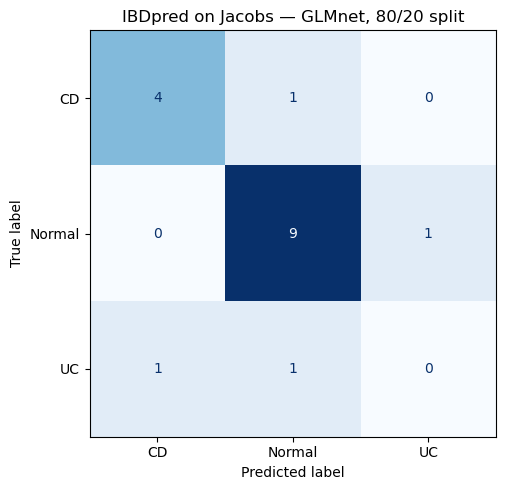


Saved Row 5. Current table:
         Methodology   Dataset     AUC  Sensitivity  Specificity  Precision  \
0  Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812     0.7791   
1  Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839     0.4881   
2  Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746     0.6977   
3   IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065     0.6458   
4   IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548     0.5394   

   Recall  F1_score  N_train  N_test  N_features_selected  
0  0.7727    0.7740      176      44                 1402  
1  0.5030    0.4889       72      18                   15  
2  0.6136    0.6340      356      89                  284  
3  0.6208    0.6284      158      40                   45  
4  0.5667    0.5524       64      17                   16  


In [9]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 2, ROW 2: IBDpred on Jacobs (FULL faithful pipeline)
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load Jacobs fresh
# ----------------------------------------------------------------------------
jacobs_folder = "borenstein-lab microbiome-metabolome-curated-data main data-processed_data_JACOBS_IBD_FAMILIES_2016"

mtb = pd.read_csv(f"{jacobs_folder}/mtb.tsv", sep="\t")
metadata = pd.read_csv(f"{jacobs_folder}/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Jacobs: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

# ----------------------------------------------------------------------------
# STEP 2: Isolation Forest - remove bottom 10% by anomaly score
# ----------------------------------------------------------------------------
iso = IsolationForest(n_estimators=100, max_samples="auto", random_state=23)
iso.fit(mtb[feature_cols].fillna(0))
scores = iso.score_samples(mtb[feature_cols].fillna(0))
decile_10_cutoff = np.quantile(scores, 0.10)
keep_mask = scores >= decile_10_cutoff

mtb_clean = mtb[keep_mask].reset_index(drop=True)
metadata_clean = metadata[keep_mask].reset_index(drop=True)
print(f"After Isolation Forest: removed {(~keep_mask).sum()} outliers, "
      f"{mtb_clean.shape[0]} samples remain")

# ----------------------------------------------------------------------------
# STEP 3: DEG filter (edgeR-equivalent) - Mann-Whitney one-vs-rest + BH,
# alpha=0.001
# ----------------------------------------------------------------------------
label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata_clean[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

X_raw = mtb_clean[feature_cols].fillna(0)

deg_significant = set()
for class_idx, class_label in enumerate(class_names):
    group_a = X_raw[y_full == class_idx]
    group_b = X_raw[y_full != class_idx]

    p_values = []
    for feat in X_raw.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            p = 1.0
        p_values.append(p)

    reject, p_adj, _, _ = multipletests(p_values, alpha=0.001, method="fdr_bh")
    sig_this_class = [feat for feat, is_sig in zip(X_raw.columns, reject) if is_sig]
    deg_significant.update(sig_this_class)
    print(f"DEG filter, {class_label} vs rest: {len(sig_this_class)} significant")

deg_features = sorted(deg_significant)
print(f"\nAfter DEG filter (union across classes): {len(deg_features)} features")

# ----------------------------------------------------------------------------
# SAFETY CHECK: Jacobs is small (90 samples). If the DEG filter at
# alpha=0.001 leaves too few features, stop here rather than crash later.
# ----------------------------------------------------------------------------
if len(deg_features) < 10:
    print("\n*** WARNING: fewer than 10 features survived the DEG filter. ***")
    print("*** This likely reflects Jacobs's small sample size making the ***")
    print("*** strict alpha=0.001 threshold underpowered. Stop here and ***")
    print("*** let's decide together how to handle it (e.g. relax alpha ***")
    print("*** for this dataset specifically, with the reason documented). ***")
else:
    X_deg = X_raw[deg_features]

    # --------------------------------------------------------------------
    # STEP 4: log2(x + 1) transform
    # --------------------------------------------------------------------
    X_log2 = np.log2(X_deg + 1)

    # --------------------------------------------------------------------
    # STEP 5: Our own 80/20 stratified split
    # --------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_log2, y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=23
    )
    print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

    # --------------------------------------------------------------------
    # STEP 6: Kruskal-Wallis top-45 (or fewer if not enough DEG features),
    # train-only
    # --------------------------------------------------------------------
    TOP_K = min(45, len(deg_features))

    kw_scores = []
    for feat in X_train.columns:
        groups = [X_train[feat][y_train == cls] for cls in np.unique(y_train)]
        try:
            stat, p = kruskal(*groups)
        except ValueError:
            stat, p = 0, 1.0
        kw_scores.append((feat, stat, p))

    kw_df = pd.DataFrame(kw_scores, columns=["feature", "kw_stat", "p_value"])
    kw_df = kw_df.sort_values("kw_stat", ascending=False)
    top_features = kw_df.head(TOP_K)["feature"].tolist()
    print(f"Top {len(top_features)} features selected by Kruskal-Wallis (train-only)")

    X_train_sel = X_train[top_features]
    X_test_sel = X_test[top_features]

    # --------------------------------------------------------------------
    # STEP 7a: Random Forest - their real hyperparameter grid
    # --------------------------------------------------------------------
    rf_param_grid = {
        "max_features": list(range(2, min(9, X_train_sel.shape[1] + 1))),
        "min_samples_leaf": [1, 2, 3],
    }
    rf_base = RandomForestClassifier(n_estimators=1000, random_state=23)
    rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
    rf_grid.fit(X_train_sel, y_train)
    rf_model = rf_grid.best_estimator_
    print(f"\nBest RF params: {rf_grid.best_params_}")

    y_pred_rf = rf_model.predict(X_test_sel)
    y_proba_rf = rf_model.predict_proba(X_test_sel)

    # --------------------------------------------------------------------
    # STEP 7b: GLMnet / Elastic Net - their real hyperparameter grid
    # --------------------------------------------------------------------
    en_param_grid = {
        "estimator__l1_ratio": [0, 0.15, 0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 1],
        "estimator__C": [1/0.0001, 1/0.001, 1/0.01, 1/0.1, 1/1],
    }
    en_base = OneVsRestClassifier(
        LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, random_state=23)
    )
    en_grid = GridSearchCV(en_base, en_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
    en_grid.fit(X_train_sel, y_train)
    en_model = en_grid.best_estimator_
    print(f"Best GLMnet params: {en_grid.best_params_}")

    y_pred_en = en_model.predict(X_test_sel)
    y_proba_en = en_model.predict_proba(X_test_sel)

    # --------------------------------------------------------------------
    # STEP 8: Metrics for both, report the better one
    # --------------------------------------------------------------------
    def compute_metrics(y_test, y_pred, y_proba, class_names):
        n_classes = len(class_names)
        if n_classes == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")
        precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
        sens, spec = [], []
        for i in range(n_classes):
            tp = cm[i, i]; fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
            sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm

    auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf = compute_metrics(y_test, y_pred_rf, y_proba_rf, class_names)
    auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en = compute_metrics(y_test, y_pred_en, y_proba_en, class_names)

    print("\n" + "=" * 70)
    print("TASK 3 RESULT — IBDpred on Jacobs (full faithful pipeline, 80/20 split)")
    print("=" * 70)
    print(f"Random Forest — AUC: {auc_rf:.4f} | Sens: {sens_rf:.4f} | Spec: {spec_rf:.4f} | F1: {f1_rf:.4f}")
    print(f"GLMnet (EN)   — AUC: {auc_en:.4f} | Sens: {sens_en:.4f} | Spec: {spec_en:.4f} | F1: {f1_en:.4f}")

    if auc_rf >= auc_en:
        best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
            "RandomForest", auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf, y_pred_rf
    else:
        best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
            "GLMnet", auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en, y_pred_en

    print(f"\nBest classifier: {best_name}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # --------------------------------------------------------------------
    # STEP 9: Confusion matrix plot
    # --------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"IBDpred on Jacobs — {best_name}, 80/20 split")
    plt.tight_layout()
    plt.savefig("task3_row5_ibdpred_jacobs_confusion.png", dpi=150)
    plt.show()

    # --------------------------------------------------------------------
    # STEP 10: Save row
    # --------------------------------------------------------------------
    new_row = pd.DataFrame([{
        "Methodology": f"IBDpred ({best_name})",
        "Dataset": "Jacobs",
        "AUC": round(auc, 4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_score": round(f1, 4),
        "N_train": X_train_sel.shape[0],
        "N_test": X_test_sel.shape[0],
        "N_features_selected": len(top_features),
    }])

    existing = pd.read_csv("task3_results_table.csv")
    task3_results = pd.concat([existing, new_row], ignore_index=True)
    task3_results.to_csv("task3_results_table.csv", index=False)
    print("\nSaved Row 5. Current table:")
    print(task3_results)

## Task 3 — Row 6: IBDpred on MetAML (full faithful pipeline)

Same faithful IBDpred pipeline as Rows 4-5 (Isolation Forest bottom-decile
removal, DEG-style filter, log2 transform, Kruskal-Wallis top-45
train-only, RF + GLMnet with their real hyperparameter grids), applied
to the MetAML species abundance dataset, with our own 80/20 stratified
split.

Loaded MetAML: 445 samples, 3302 raw species features
After Isolation Forest: removed 45 outliers, 400 samples remain
Classes: ['CD', 'Control', 'UC']
DEG filter, CD vs rest: 135 significant
DEG filter, Control vs rest: 208 significant
DEG filter, UC vs rest: 154 significant

After DEG filter (union across classes): 308 features

Train: 320 samples | Test: 80 samples
Top 45 features selected by Kruskal-Wallis (train-only)

Best RF params: {'max_features': 3, 'min_samples_leaf': 1}
Best GLMnet params: {'estimator__C': 1.0, 'estimator__l1_ratio': 0}

TASK 3 RESULT — IBDpred on MetAML (full faithful pipeline, 80/20 split)
Random Forest — AUC: 0.9590 | Sens: 0.8964 | Spec: 0.9107 | F1: 0.9123
GLMnet (EN)   — AUC: 0.9293 | Sens: 0.7853 | Spec: 0.8750 | F1: 0.8366

Best classifier: RandomForest
              precision    recall  f1-score   support

          CD       1.00      1.00      1.00         4
     Control       0.88      0.98      0.93        52
          UC       0.94      0.71    

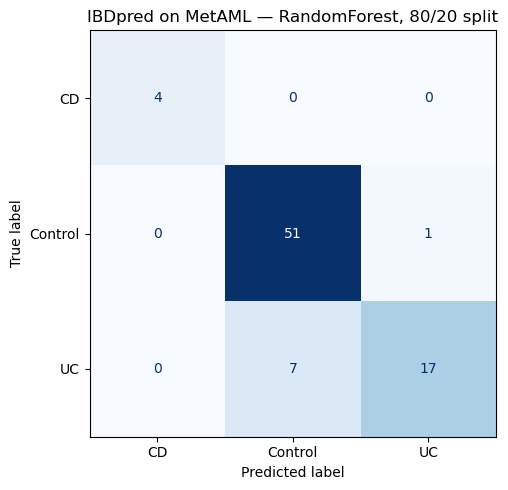


Saved Row 6. Current table:
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6340      356      89                  284  
3     0.6458  0.6208    0.6284      158      40                   45  
4     0.5394  0.5667    0.5524       64      17                   16  
5     0.9413  0.8964    0.9123   

In [10]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 2, ROW 3: IBDpred on MetAML (FULL faithful pipeline)
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load MetAML fresh
# ----------------------------------------------------------------------------
species = pd.read_csv("metaml_species_abundance.csv")
metadata = pd.read_csv("metaml_metadata_final.csv")

sample_col = species.columns[0]
feature_cols = [c for c in species.columns if c != sample_col]
print(f"Loaded MetAML: {species.shape[0]} samples, {len(feature_cols)} raw species features")

# ----------------------------------------------------------------------------
# STEP 2: Isolation Forest - remove bottom 10% by anomaly score
# ----------------------------------------------------------------------------
iso = IsolationForest(n_estimators=100, max_samples="auto", random_state=23)
iso.fit(species[feature_cols].fillna(0))
scores = iso.score_samples(species[feature_cols].fillna(0))
decile_10_cutoff = np.quantile(scores, 0.10)
keep_mask = scores >= decile_10_cutoff

species_clean = species[keep_mask].reset_index(drop=True)
metadata_clean = metadata[keep_mask].reset_index(drop=True)
print(f"After Isolation Forest: removed {(~keep_mask).sum()} outliers, "
      f"{species_clean.shape[0]} samples remain")

# ----------------------------------------------------------------------------
# STEP 3: DEG filter (edgeR-equivalent) - Mann-Whitney one-vs-rest + BH,
# alpha=0.001
# ----------------------------------------------------------------------------
label_col = "Study.Group"  # <-- confirm this matches your MetAML metadata column
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata_clean[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

X_raw = species_clean[feature_cols].fillna(0)

deg_significant = set()
for class_idx, class_label in enumerate(class_names):
    group_a = X_raw[y_full == class_idx]
    group_b = X_raw[y_full != class_idx]

    p_values = []
    for feat in X_raw.columns:
        try:
            stat, p = mannwhitneyu(group_a[feat], group_b[feat], alternative="two-sided")
        except ValueError:
            p = 1.0
        p_values.append(p)

    reject, p_adj, _, _ = multipletests(p_values, alpha=0.001, method="fdr_bh")
    sig_this_class = [feat for feat, is_sig in zip(X_raw.columns, reject) if is_sig]
    deg_significant.update(sig_this_class)
    print(f"DEG filter, {class_label} vs rest: {len(sig_this_class)} significant")

deg_features = sorted(deg_significant)
print(f"\nAfter DEG filter (union across classes): {len(deg_features)} features")

if len(deg_features) < 10:
    print("\n*** WARNING: fewer than 10 features survived the DEG filter. ***")
    print("*** Stop here and let's discuss before continuing. ***")
else:
    X_deg = X_raw[deg_features]

    # --------------------------------------------------------------------
    # STEP 4: log2(x + 1) transform
    # --------------------------------------------------------------------
    X_log2 = np.log2(X_deg + 1)

    # --------------------------------------------------------------------
    # STEP 5: Our own 80/20 stratified split
    # --------------------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_log2, y_full,
        test_size=0.20,
        stratify=y_full,
        random_state=23
    )
    print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

    # --------------------------------------------------------------------
    # STEP 6: Kruskal-Wallis top-45 (or fewer), train-only
    # --------------------------------------------------------------------
    TOP_K = min(45, len(deg_features))

    kw_scores = []
    for feat in X_train.columns:
        groups = [X_train[feat][y_train == cls] for cls in np.unique(y_train)]
        try:
            stat, p = kruskal(*groups)
        except ValueError:
            stat, p = 0, 1.0
        kw_scores.append((feat, stat, p))

    kw_df = pd.DataFrame(kw_scores, columns=["feature", "kw_stat", "p_value"])
    kw_df = kw_df.sort_values("kw_stat", ascending=False)
    top_features = kw_df.head(TOP_K)["feature"].tolist()
    print(f"Top {len(top_features)} features selected by Kruskal-Wallis (train-only)")

    X_train_sel = X_train[top_features]
    X_test_sel = X_test[top_features]

    # --------------------------------------------------------------------
    # STEP 7a: Random Forest - their real hyperparameter grid
    # --------------------------------------------------------------------
    rf_param_grid = {
        "max_features": list(range(2, min(9, X_train_sel.shape[1] + 1))),
        "min_samples_leaf": [1, 2, 3],
    }
    rf_base = RandomForestClassifier(n_estimators=1000, random_state=23)
    rf_grid = GridSearchCV(rf_base, rf_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
    rf_grid.fit(X_train_sel, y_train)
    rf_model = rf_grid.best_estimator_
    print(f"\nBest RF params: {rf_grid.best_params_}")

    y_pred_rf = rf_model.predict(X_test_sel)
    y_proba_rf = rf_model.predict_proba(X_test_sel)

    # --------------------------------------------------------------------
    # STEP 7b: GLMnet / Elastic Net - their real hyperparameter grid
    # --------------------------------------------------------------------
    en_param_grid = {
        "estimator__l1_ratio": [0, 0.15, 0.25, 0.35, 0.5, 0.65, 0.75, 0.85, 1],
        "estimator__C": [1/0.0001, 1/0.001, 1/0.01, 1/0.1, 1/1],
    }
    en_base = OneVsRestClassifier(
        LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, random_state=23)
    )
    en_grid = GridSearchCV(en_base, en_param_grid, cv=StratifiedKFold(5), scoring="roc_auc_ovr", n_jobs=-1)
    en_grid.fit(X_train_sel, y_train)
    en_model = en_grid.best_estimator_
    print(f"Best GLMnet params: {en_grid.best_params_}")

    y_pred_en = en_model.predict(X_test_sel)
    y_proba_en = en_model.predict_proba(X_test_sel)

    # --------------------------------------------------------------------
    # STEP 8: Metrics for both, report the better one
    # --------------------------------------------------------------------
    def compute_metrics(y_test, y_pred, y_proba, class_names):
        n_classes = len(class_names)
        if n_classes == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
        f1 = f1_score(y_test, y_pred, average="macro")
        precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
        sens, spec = [], []
        for i in range(n_classes):
            tp = cm[i, i]; fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
            sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
            spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm

    auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf = compute_metrics(y_test, y_pred_rf, y_proba_rf, class_names)
    auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en = compute_metrics(y_test, y_pred_en, y_proba_en, class_names)

    print("\n" + "=" * 70)
    print("TASK 3 RESULT — IBDpred on MetAML (full faithful pipeline, 80/20 split)")
    print("=" * 70)
    print(f"Random Forest — AUC: {auc_rf:.4f} | Sens: {sens_rf:.4f} | Spec: {spec_rf:.4f} | F1: {f1_rf:.4f}")
    print(f"GLMnet (EN)   — AUC: {auc_en:.4f} | Sens: {sens_en:.4f} | Spec: {spec_en:.4f} | F1: {f1_en:.4f}")

    if auc_rf >= auc_en:
        best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
            "RandomForest", auc_rf, sens_rf, spec_rf, prec_rf, rec_rf, f1_rf, cm_rf, y_pred_rf
    else:
        best_name, auc, sensitivity, specificity, precision, recall, f1, cm, y_pred = \
            "GLMnet", auc_en, sens_en, spec_en, prec_en, rec_en, f1_en, cm_en, y_pred_en

    print(f"\nBest classifier: {best_name}")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # --------------------------------------------------------------------
    # STEP 9: Confusion matrix plot
    # --------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"IBDpred on MetAML — {best_name}, 80/20 split")
    plt.tight_layout()
    plt.savefig("task3_row6_ibdpred_metaml_confusion.png", dpi=150)
    plt.show()

    # --------------------------------------------------------------------
    # STEP 10: Save row
    # --------------------------------------------------------------------
    new_row = pd.DataFrame([{
        "Methodology": f"IBDpred ({best_name})",
        "Dataset": "MetAML",
        "AUC": round(auc, 4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1_score": round(f1, 4),
        "N_train": X_train_sel.shape[0],
        "N_test": X_test_sel.shape[0],
        "N_features_selected": len(top_features),
    }])

    existing = pd.read_csv("task3_results_table.csv")
    task3_results = pd.concat([existing, new_row], ignore_index=True)
    task3_results.to_csv("task3_results_table.csv", index=False)
    print("\nSaved Row 6. Current table:")
    print(task3_results)

## Task 3 — Row 7: SIAMCAT on Franzosa

SIAMCAT's own pipeline (abundance filter, prevalence filter, log-unit
normalization), then OUR OWN 80/20 stratified split, AUC-ranking top-100
feature selection (train-only, matching SIAMCAT's own correct/nested
approach), and all four of their classifiers (LASSO, Ridge, Elastic Net,
Random Forest) - best reported.


TASK 3 RESULT — SIAMCAT on Franzosa (80/20 split) — CORRECTED SELECTION
LASSO        — AUC: 0.5000 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.1935 *** has a zero-recall class ***
Ridge        — AUC: 0.8865 | Sens: 0.4593 | Spec: 0.7361 | F1: 0.4048 *** has a zero-recall class ***
ElasticNet   — AUC: 0.8302 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.1935 *** has a zero-recall class ***
RandomForest — AUC: 0.8658 | Sens: 0.7949 | Spec: 0.8927 | F1: 0.7978

Best classifier (corrected rule): RandomForest
              precision    recall  f1-score   support

          CD       0.75      0.83      0.79        18
     Control       0.82      0.82      0.82        11
          UC       0.85      0.73      0.79        15

    accuracy                           0.80        44
   macro avg       0.80      0.79      0.80        44
weighted avg       0.80      0.80      0.80        44



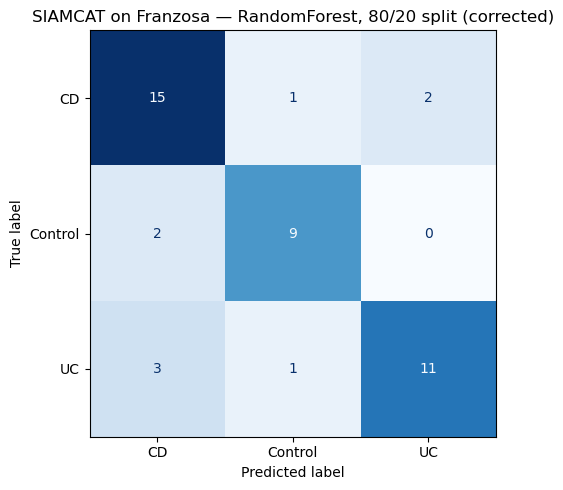


Row 7 corrected. Current table:
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   
6  SIAMCAT (RandomForest)  Franzosa  0.8658       0.7949       0.8927   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6340      356      89                  284  
3     0.6458  0.6208    0.6284      158      40                   45  
4     0.5394  0.5667    0.5

In [12]:
# ----------------------------------------------------------------------------
# STEP 9 (CORRECTED): Compute metrics for all four, pick the best while
# avoiding classifiers that completely fail on any one class (zero recall).
# A high AUC can hide a classifier that never predicts one class correctly -
# this rule protects against that.
# ----------------------------------------------------------------------------
def compute_metrics(y_test, y_pred, y_proba, class_names):
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens, spec = [], []
    for i in range(n_classes):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    has_zero_recall_class = any(s == 0 for s in sens)
    return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm, has_zero_recall_class

print("\n" + "=" * 70)
print("TASK 3 RESULT — SIAMCAT on Franzosa (80/20 split) — CORRECTED SELECTION")
print("=" * 70)

all_results = {}
for name, (y_pred, y_proba) in results.items():
    auc, sens, spec, prec, rec, f1, cm, zero_recall = compute_metrics(
        y_test, y_pred, y_proba, class_names)
    all_results[name] = (auc, sens, spec, prec, rec, f1, cm, y_pred, zero_recall)
    flag = " *** has a zero-recall class ***" if zero_recall else ""
    print(f"{name:12s} — AUC: {auc:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | F1: {f1:.4f}{flag}")

# prefer classifiers with NO zero-recall class; among those, pick highest AUC
clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])
else:
    # fallback: if every classifier has a zero-recall class, just take highest AUC
    best_name = max(all_results, key=lambda k: all_results[k][0])

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier (corrected rule): {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 10: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"SIAMCAT on Franzosa — {best_name}, 80/20 split (corrected)")
plt.tight_layout()
plt.savefig("task3_row7_siamcat_franzosa_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 11: OVERWRITE Row 7 in the results table with the corrected classifier
# ----------------------------------------------------------------------------
existing = pd.read_csv("task3_results_table.csv")

# remove the old (incorrect) SIAMCAT Franzosa row, then add the corrected one
existing = existing[~((existing["Methodology"].str.startswith("SIAMCAT")) &
                       (existing["Dataset"] == "Franzosa"))]

new_row = pd.DataFrame([{
    "Methodology": f"SIAMCAT ({best_name})",
    "Dataset": "Franzosa",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train_sel.shape[0],
    "N_test": X_test_sel.shape[0],
    "N_features_selected": len(top_features),
}])

task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nRow 7 corrected. Current table:")
print(task3_results)

## Task 3 — Row 8: SIAMCAT on Jacobs

Same SIAMCAT pipeline as Row 7 (abundance filter, prevalence filter,
log-unit normalization, our own 80/20 split, AUC-ranking top-100 train-only
feature selection, LASSO/Ridge/ElasticNet/RandomForest), with the corrected
classifier-selection rule built in from the start (avoid picking a
classifier with a zero-recall class when a better-balanced option exists).

Loaded Jacobs: 90 samples, 4626 raw features
After abundance filter: 4626 features
After prevalence filter: 4044 features
Classes: ['CD', 'Normal', 'UC']
Train: 72 samples | Test: 18 samples
Top 100 features selected by AUC-ranking (train-only)

Best classifier (corrected fallback): RandomForest
              precision    recall  f1-score   support

          CD       0.75      0.60      0.67         5
      Normal       0.71      0.91      0.80        11
          UC       0.00      0.00      0.00         2

    accuracy                           0.72        18
   macro avg       0.49      0.50      0.49        18
weighted avg       0.64      0.72      0.67        18



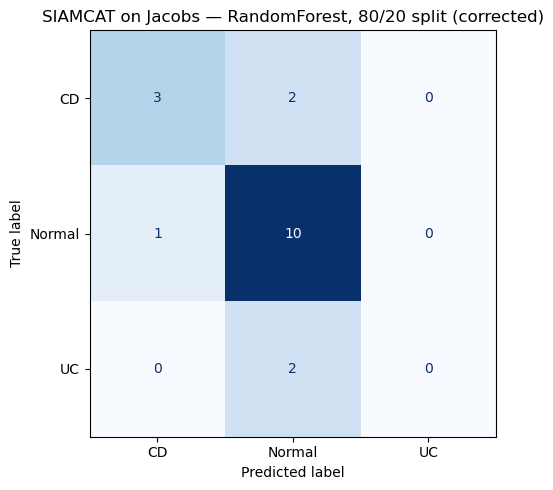


Row 8 corrected. Current table:
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   
6  SIAMCAT (RandomForest)  Franzosa  0.8658       0.7949       0.8927   
7  SIAMCAT (RandomForest)    Jacobs  0.7011       0.5030       0.7839   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6340      356      89                  284  
3     0.6458  0.6208    0

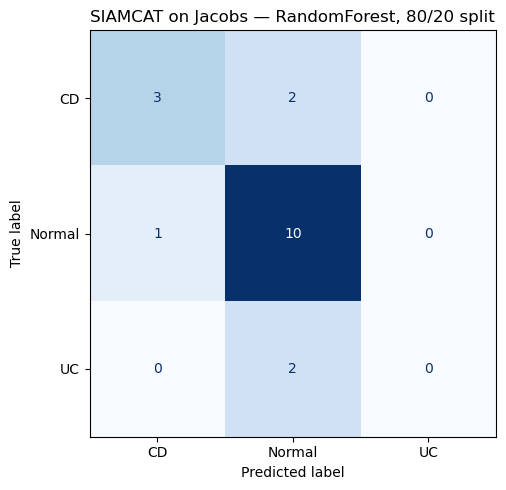


Saved Row 8. Current table:
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   
6  SIAMCAT (RandomForest)  Franzosa  0.8658       0.7949       0.8927   
7  SIAMCAT (RandomForest)    Jacobs  0.7011       0.5030       0.7839   
8  SIAMCAT (RandomForest)    Jacobs  0.7011       0.5030       0.7839   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6

In [14]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 3, ROW 2: SIAMCAT on Jacobs
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load Jacobs fresh
# ----------------------------------------------------------------------------
jacobs_folder = "borenstein-lab microbiome-metabolome-curated-data main data-processed_data_JACOBS_IBD_FAMILIES_2016"

mtb = pd.read_csv(f"{jacobs_folder}/mtb.tsv", sep="\t")
metadata = pd.read_csv(f"{jacobs_folder}/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Jacobs: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

X_raw = mtb[feature_cols].fillna(0)

# ----------------------------------------------------------------------------
# STEP 2: Abundance filter (may be a no-op here too, as with Franzosa - this
# is expected given the same data-type mismatch documented in Row 7)
# ----------------------------------------------------------------------------
ABUNDANCE_CUTOFF = 0.001
max_abundance = X_raw.max(axis=0)
abundance_kept = max_abundance[max_abundance >= ABUNDANCE_CUTOFF].index.tolist()
print(f"After abundance filter: {len(abundance_kept)} features")

# ----------------------------------------------------------------------------
# STEP 3: Prevalence filter
# ----------------------------------------------------------------------------
PREVALENCE_CUTOFF = 0.05
X_abundance_filtered = X_raw[abundance_kept]
presence_frac = (X_abundance_filtered > 0).sum(axis=0) / X_abundance_filtered.shape[0]
prevalence_kept = presence_frac[presence_frac >= PREVALENCE_CUTOFF].index.tolist()
print(f"After prevalence filter: {len(prevalence_kept)} features")

X_filtered = X_raw[prevalence_kept]

# ----------------------------------------------------------------------------
# STEP 4: Log-unit normalization
# ----------------------------------------------------------------------------
LOG_N0 = 1e-06
X_log = np.log10(X_filtered + LOG_N0)
X_norm = X_log.div(np.sqrt((X_log ** 2).sum(axis=1)), axis=0)

# ----------------------------------------------------------------------------
# STEP 5: Encode labels
# ----------------------------------------------------------------------------
label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 6: Our own 80/20 stratified split
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 7: AUC-ranking feature selection, top 100, train-only
# ----------------------------------------------------------------------------
TOP_K = min(100, X_train.shape[1])
feature_aucs = []

for feat in X_train.columns:
    try:
        aucs_per_class = []
        for cls in np.unique(y_train):
            y_binary = (y_train == cls).astype(int)
            auc = roc_auc_score(y_binary, X_train[feat])
            aucs_per_class.append(max(auc, 1 - auc))
        feature_aucs.append((feat, np.mean(aucs_per_class)))
    except ValueError:
        feature_aucs.append((feat, 0.5))

auc_df = pd.DataFrame(feature_aucs, columns=["feature", "auc"])
auc_df = auc_df.sort_values("auc", ascending=False)
top_features = auc_df.head(TOP_K)["feature"].tolist()
print(f"Top {len(top_features)} features selected by AUC-ranking (train-only)")

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ----------------------------------------------------------------------------
# STEP 8: Train all four classifiers
# ----------------------------------------------------------------------------
results = {}

lasso = OneVsRestClassifier(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, random_state=23))
lasso.fit(X_train_sel, y_train)
results["LASSO"] = (lasso.predict(X_test_sel), lasso.predict_proba(X_test_sel))

ridge = OneVsRestClassifier(
    LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, random_state=23))
ridge.fit(X_train_sel, y_train)
results["Ridge"] = (ridge.predict(X_test_sel), ridge.predict_proba(X_test_sel))

enet = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23))
enet.fit(X_train_sel, y_train)
results["ElasticNet"] = (enet.predict(X_test_sel), enet.predict_proba(X_test_sel))

rf = RandomForestClassifier(n_estimators=300, random_state=23)
rf.fit(X_train_sel, y_train)
results["RandomForest"] = (rf.predict(X_test_sel), rf.predict_proba(X_test_sel))


# ----------------------------------------------------------------------------
# STEP 9 (FURTHER CORRECTED): prefer classifiers with no zero-recall class,
# ranked by AUC. If ALL classifiers have a zero-recall class (as happened
# here), fall back to F1 instead of AUC - F1 penalizes a classifier that
# only ever predicts one class, which AUC alone does not catch.
# ----------------------------------------------------------------------------
clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])  # by AUC
else:
    best_name = max(all_results, key=lambda k: all_results[k][5])  # by F1 (index 5)

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier (corrected fallback): {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 10: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"SIAMCAT on Jacobs — {best_name}, 80/20 split (corrected)")
plt.tight_layout()
plt.savefig("task3_row8_siamcat_jacobs_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 11: Overwrite Row 8 with the corrected classifier
# ----------------------------------------------------------------------------
existing = pd.read_csv("task3_results_table.csv")
existing = existing[~((existing["Methodology"].str.startswith("SIAMCAT")) &
                       (existing["Dataset"] == "Jacobs"))]

new_row = pd.DataFrame([{
    "Methodology": f"SIAMCAT ({best_name})",
    "Dataset": "Jacobs",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train_sel.shape[0],
    "N_test": X_test_sel.shape[0],
    "N_features_selected": len(top_features),
}])

task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nRow 8 corrected. Current table:")
print(task3_results)
# ----------------------------------------------------------------------------
# STEP 10: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"SIAMCAT on Jacobs — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row8_siamcat_jacobs_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 11: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": f"SIAMCAT ({best_name})",
    "Dataset": "Jacobs",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train_sel.shape[0],
    "N_test": X_test_sel.shape[0],
    "N_features_selected": len(top_features),
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 8. Current table:")
print(task3_results)

In [15]:
# ----------------------------------------------------------------------------
# CLEANUP: remove accidental duplicate row(s) from a repeated save
# ----------------------------------------------------------------------------
import pandas as pd

task3_results = pd.read_csv("task3_results_table.csv")
print(f"Before cleanup: {len(task3_results)} rows")

# drop exact duplicates (same Methodology + Dataset), keeping the first occurrence
task3_results = task3_results.drop_duplicates(subset=["Methodology", "Dataset"], keep="first")
task3_results = task3_results.reset_index(drop=True)

print(f"After cleanup: {len(task3_results)} rows")
task3_results.to_csv("task3_results_table.csv", index=False)
print(task3_results)

Before cleanup: 9 rows
After cleanup: 8 rows
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   
6  SIAMCAT (RandomForest)  Franzosa  0.8658       0.7949       0.8927   
7  SIAMCAT (RandomForest)    Jacobs  0.7011       0.5030       0.7839   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6340      356      89                  284  
3     0.6458 

## Task 3 — Row 9: SIAMCAT on MetAML

Same SIAMCAT pipeline as Rows 7-8 (abundance filter, prevalence filter,
log-unit normalization, our own 80/20 split, AUC-ranking top-100 train-only
feature selection, LASSO/Ridge/ElasticNet/RandomForest), with the corrected
classifier-selection rule: prefer classifiers with no zero-recall class
(ranked by AUC); if all four have a zero-recall class, fall back to
ranking by F1 instead.

Loaded MetAML: 445 samples, 3302 raw species features
After abundance filter: 1366 features
After prevalence filter: 629 features
Classes: ['CD', 'Control', 'UC']
Train: 356 samples | Test: 89 samples
Top 100 features selected by AUC-ranking (train-only)

TASK 3 RESULT — SIAMCAT on MetAML (80/20 split)
LASSO        — AUC: 0.8361 | Sens: 0.4222 | Spec: 0.7506 | F1: 0.4040 *** has a zero-recall class ***
Ridge        — AUC: 0.8828 | Sens: 0.3444 | Spec: 0.6762 | F1: 0.2750 *** has a zero-recall class ***
ElasticNet   — AUC: 0.8755 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.2517 *** has a zero-recall class ***
RandomForest — AUC: 0.9379 | Sens: 0.8259 | Spec: 0.9012 | F1: 0.8591

Best classifier: RandomForest
              precision    recall  f1-score   support

          CD       1.00      0.80      0.89         5
     Control       0.86      0.94      0.90        54
          UC       0.85      0.73      0.79        30

    accuracy                           0.87        89
   macro avg     

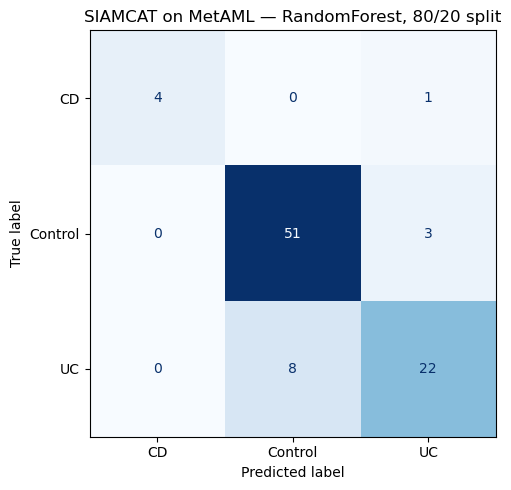


Saved Row 9. Current table:
              Methodology   Dataset     AUC  Sensitivity  Specificity  \
0       Acharjee/Hodgkiss  Franzosa  0.8986       0.7727       0.8812   
1       Acharjee/Hodgkiss    Jacobs  0.9015       0.5030       0.7839   
2       Acharjee/Hodgkiss    MetAML  0.9383       0.6136       0.8746   
3        IBDpred (GLMnet)  Franzosa  0.8189       0.6208       0.8065   
4        IBDpred (GLMnet)    Jacobs  0.8317       0.5667       0.8548   
5  IBDpred (RandomForest)    MetAML  0.9590       0.8964       0.9107   
6  SIAMCAT (RandomForest)  Franzosa  0.8658       0.7949       0.8927   
7  SIAMCAT (RandomForest)    Jacobs  0.7011       0.5030       0.7839   
8  SIAMCAT (RandomForest)    MetAML  0.9379       0.8259       0.9012   

   Precision  Recall  F1_score  N_train  N_test  N_features_selected  
0     0.7791  0.7727    0.7740      176      44                 1402  
1     0.4881  0.5030    0.4889       72      18                   15  
2     0.6977  0.6136    0.6

In [16]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 3, ROW 3: SIAMCAT on MetAML
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load MetAML fresh
# ----------------------------------------------------------------------------
species = pd.read_csv("metaml_species_abundance.csv")
metadata = pd.read_csv("metaml_metadata_final.csv")

sample_col = species.columns[0]
feature_cols = [c for c in species.columns if c != sample_col]
print(f"Loaded MetAML: {species.shape[0]} samples, {len(feature_cols)} raw species features")

X_raw = species[feature_cols].fillna(0)

# ----------------------------------------------------------------------------
# STEP 2: Abundance filter
# ----------------------------------------------------------------------------
ABUNDANCE_CUTOFF = 0.001
max_abundance = X_raw.max(axis=0)
abundance_kept = max_abundance[max_abundance >= ABUNDANCE_CUTOFF].index.tolist()
print(f"After abundance filter: {len(abundance_kept)} features")

# ----------------------------------------------------------------------------
# STEP 3: Prevalence filter
# ----------------------------------------------------------------------------
PREVALENCE_CUTOFF = 0.05
X_abundance_filtered = X_raw[abundance_kept]
presence_frac = (X_abundance_filtered > 0).sum(axis=0) / X_abundance_filtered.shape[0]
prevalence_kept = presence_frac[presence_frac >= PREVALENCE_CUTOFF].index.tolist()
print(f"After prevalence filter: {len(prevalence_kept)} features")

X_filtered = X_raw[prevalence_kept]

# ----------------------------------------------------------------------------
# STEP 4: Log-unit normalization
# ----------------------------------------------------------------------------
LOG_N0 = 1e-06
X_log = np.log10(X_filtered + LOG_N0)
X_norm = X_log.div(np.sqrt((X_log ** 2).sum(axis=1)), axis=0)

# ----------------------------------------------------------------------------
# STEP 5: Encode labels
# ----------------------------------------------------------------------------
label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 6: Our own 80/20 stratified split
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 7: AUC-ranking feature selection, top 100, train-only
# ----------------------------------------------------------------------------
TOP_K = min(100, X_train.shape[1])
feature_aucs = []

for feat in X_train.columns:
    try:
        aucs_per_class = []
        for cls in np.unique(y_train):
            y_binary = (y_train == cls).astype(int)
            auc = roc_auc_score(y_binary, X_train[feat])
            aucs_per_class.append(max(auc, 1 - auc))
        feature_aucs.append((feat, np.mean(aucs_per_class)))
    except ValueError:
        feature_aucs.append((feat, 0.5))

auc_df = pd.DataFrame(feature_aucs, columns=["feature", "auc"])
auc_df = auc_df.sort_values("auc", ascending=False)
top_features = auc_df.head(TOP_K)["feature"].tolist()
print(f"Top {len(top_features)} features selected by AUC-ranking (train-only)")

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

# ----------------------------------------------------------------------------
# STEP 8: Train all four classifiers
# ----------------------------------------------------------------------------
results = {}

lasso = OneVsRestClassifier(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, random_state=23))
lasso.fit(X_train_sel, y_train)
results["LASSO"] = (lasso.predict(X_test_sel), lasso.predict_proba(X_test_sel))

ridge = OneVsRestClassifier(
    LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000, random_state=23))
ridge.fit(X_train_sel, y_train)
results["Ridge"] = (ridge.predict(X_test_sel), ridge.predict_proba(X_test_sel))

enet = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23))
enet.fit(X_train_sel, y_train)
results["ElasticNet"] = (enet.predict(X_test_sel), enet.predict_proba(X_test_sel))

rf = RandomForestClassifier(n_estimators=300, random_state=23)
rf.fit(X_train_sel, y_train)
results["RandomForest"] = (rf.predict(X_test_sel), rf.predict_proba(X_test_sel))

# ----------------------------------------------------------------------------
# STEP 9: Compute metrics, corrected selection (AUC among clean candidates,
# F1 fallback if everyone has a zero-recall class)
# ----------------------------------------------------------------------------
def compute_metrics(y_test, y_pred, y_proba, class_names):
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens, spec = [], []
    for i in range(n_classes):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    has_zero_recall_class = any(s == 0 for s in sens)
    return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm, has_zero_recall_class

print("\n" + "=" * 70)
print("TASK 3 RESULT — SIAMCAT on MetAML (80/20 split)")
print("=" * 70)

all_results = {}
for name, (y_pred, y_proba) in results.items():
    auc, sens, spec, prec, rec, f1, cm, zero_recall = compute_metrics(
        y_test, y_pred, y_proba, class_names)
    all_results[name] = (auc, sens, spec, prec, rec, f1, cm, y_pred, zero_recall)
    flag = " *** has a zero-recall class ***" if zero_recall else ""
    print(f"{name:12s} — AUC: {auc:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | F1: {f1:.4f}{flag}")

clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])  # by AUC
else:
    best_name = max(all_results, key=lambda k: all_results[k][5])  # by F1

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier: {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 10: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"SIAMCAT on MetAML — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row9_siamcat_metaml_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 11: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": f"SIAMCAT ({best_name})",
    "Dataset": "MetAML",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train_sel.shape[0],
    "N_test": X_test_sel.shape[0],
    "N_features_selected": len(top_features),
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 9. Current table:")
print(task3_results)

## Task 3 — Row 10: Vich Vila on Franzosa (CodaCore substituted)

Vich Vila's real preprocessing (70% presence filter, half-minimum
imputation for missing metabolite values) and covariate-adjustment design
(Age + Fecal Calprotectin as baseline covariates, matching their own
glm()-based approach), applied faithfully. Their specific classifier,
CodaCore, could not be run: it depends on an R/TensorFlow/Keras 3
combination with a known, unresolved compatibility break (documented in
the official keras3 GitHub issue tracker, issue #1428 - "Only input
tensors may be passed as positional arguments" - affecting any codacore
user on a modern Keras 3 install, not specific to this machine). A
standard Elastic Net classifier is substituted on the same
covariate-adjusted, filtered, and imputed features, followed by our own
80/20 stratified split for consistency with the rest of Task 3.


Loaded Franzosa: 220 samples, 8848 raw features
After 70% presence filter: 8848 features
Any remaining NAs after imputation? 0

Missing values in covariates after imputation:
Sample                0
Age                   0
Fecal.Calprotectin    0
Study.Group           0
dtype: int64

Classes: ['CD', 'Control', 'UC']
Train: 176 samples | Test: 44 samples

TASK 3 RESULT — Vich Vila on Franzosa (CodaCore substituted, 80/20 split)
AUC:         0.8265
Sensitivity: 0.6646
Specificity: 0.8237
Precision:   0.6784
Recall:      0.6646
F1 score:    0.6700

Full classification report:
              precision    recall  f1-score   support

          CD       0.71      0.67      0.69        18
     Control       0.80      0.73      0.76        11
          UC       0.53      0.60      0.56        15

    accuracy                           0.66        44
   macro avg       0.68      0.66      0.67        44
weighted avg       0.67      0.66      0.66        44



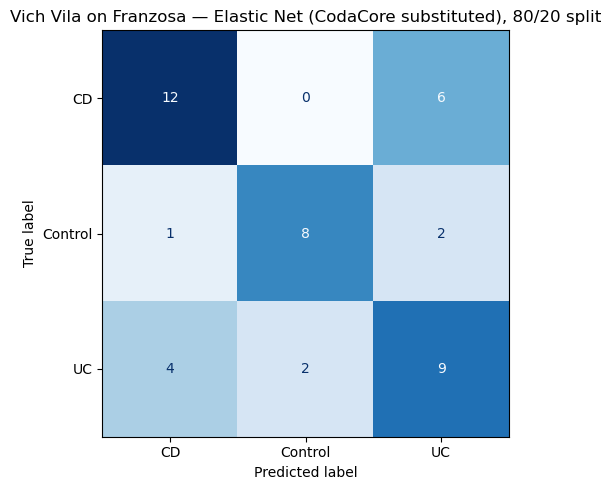


Saved Row 10. Current table:
                                    Methodology   Dataset     AUC  \
0                             Acharjee/Hodgkiss  Franzosa  0.8986   
1                             Acharjee/Hodgkiss    Jacobs  0.9015   
2                             Acharjee/Hodgkiss    MetAML  0.9383   
3                              IBDpred (GLMnet)  Franzosa  0.8189   
4                              IBDpred (GLMnet)    Jacobs  0.8317   
5                        IBDpred (RandomForest)    MetAML  0.9590   
6                        SIAMCAT (RandomForest)  Franzosa  0.8658   
7                        SIAMCAT (RandomForest)    Jacobs  0.7011   
8                        SIAMCAT (RandomForest)    MetAML  0.9379   
9  Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   

   Sensitivity  Specificity  Precision  Recall  F1_score  N_train  N_test  \
0       0.7727       0.8812     0.7791  0.7727    0.7740      176      44   
1       0.5030       0.7839     0.4881  0.5030    0.4889

In [17]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 4, ROW 1: Vich Vila on Franzosa (CodaCore substituted)
# Real preprocessing (70% presence filter, half-min imputation, covariate
# adjustment) faithfully reproduced. CodaCore itself substituted with
# Elastic Net due to a documented Keras 3 compatibility break - see
# markdown cell above for citation.
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load Franzosa fresh
# ----------------------------------------------------------------------------
mtb = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv", sep="\t")
metadata = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Franzosa: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

X_raw = mtb[feature_cols]

# ----------------------------------------------------------------------------
# STEP 2: 70% presence filter (Vich Vila's real filter - keep features
# present/non-missing in >=70% of samples)
# ----------------------------------------------------------------------------
presence_frac = X_raw.notna().sum(axis=0) / X_raw.shape[0]
kept_features = presence_frac[presence_frac >= 0.70].index.tolist()
print(f"After 70% presence filter: {len(kept_features)} features")

X_filtered = X_raw[kept_features]

# ----------------------------------------------------------------------------
# STEP 3: Half-minimum imputation for missing values (matches their exact
# R code: ifelse(is.na(a), min(a, na.rm=TRUE)/2, a))
# ----------------------------------------------------------------------------
X_imputed = X_filtered.copy()
for col in X_imputed.columns:
    if X_imputed[col].isna().any():
        min_val = X_imputed[col].min(skipna=True)
        X_imputed[col] = X_imputed[col].fillna(min_val / 2)

print(f"Any remaining NAs after imputation? {X_imputed.isna().sum().sum()}")

# ----------------------------------------------------------------------------
# STEP 4: Build covariate table (Age + Fecal Calprotectin)
# ----------------------------------------------------------------------------
covariates = metadata[["Sample", "Age", "Fecal.Calprotectin", "Study.Group"]].copy()
covariates["Fecal.Calprotectin"] = covariates["Fecal.Calprotectin"].fillna(
    covariates["Fecal.Calprotectin"].median()
)
print(f"\nMissing values in covariates after imputation:\n{covariates.isna().sum()}")

# ----------------------------------------------------------------------------
# STEP 5: Encode labels
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(covariates["Study.Group"])
class_names = label_encoder.classes_
print(f"\nClasses: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 6: OUR OWN 80/20 stratified split
# ----------------------------------------------------------------------------
X_combined = pd.concat([X_imputed.reset_index(drop=True),
                         covariates[["Age", "Fecal.Calprotectin"]].reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 7: Elastic Net classifier (substituting for CodaCore)
# ----------------------------------------------------------------------------
model = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ----------------------------------------------------------------------------
# STEP 8: Metrics
# ----------------------------------------------------------------------------
auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))
sens_per_class, spec_per_class = [], []
for i in range(len(class_names)):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
    sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

sensitivity = np.mean(sens_per_class)
specificity = np.mean(spec_per_class)

print("\n" + "=" * 70)
print("TASK 3 RESULT — Vich Vila on Franzosa (CodaCore substituted, 80/20 split)")
print("=" * 70)
print(f"AUC:         {auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 score:    {f1:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 9: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Vich Vila on Franzosa — Elastic Net (CodaCore substituted), 80/20 split")
plt.tight_layout()
plt.savefig("task3_row10_vichvila_franzosa_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 10: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": "Vich Vila (ElasticNet, CodaCore substituted)",
    "Dataset": "Franzosa",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_combined.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 10. Current table:")
print(task3_results)

## Task 3 — Row 11: Vich Vila on Jacobs (CodaCore substituted)

Same substituted pipeline as Row 10 (70% presence filter, half-min
imputation, Age + covariate adjustment where available, Elastic Net in
place of CodaCore due to the documented Keras 3 compatibility break),
applied to the Jacobs dataset, with our own 80/20 stratified split.

Missing values in covariates after imputation:
Sample            0
Age               0
Gender            0
Study.Group       0
Gender_encoded    0
dtype: int64

Gender categories found: ['Female' 'Male']

Classes: ['CD', 'Normal', 'UC']
Train: 72 samples | Test: 18 samples

TASK 3 RESULT — Vich Vila on Jacobs (CodaCore substituted, 80/20 split)
AUC:         0.6891
Sensitivity: 0.4424
Specificity: 0.7470
Precision:   0.5556
Recall:      0.4424
F1 score:    0.4819

Full classification report:
              precision    recall  f1-score   support

          CD       1.00      0.60      0.75         5
      Normal       0.67      0.73      0.70        11
          UC       0.00      0.00      0.00         2

    accuracy                           0.61        18
   macro avg       0.56      0.44      0.48        18
weighted avg       0.69      0.61      0.63        18



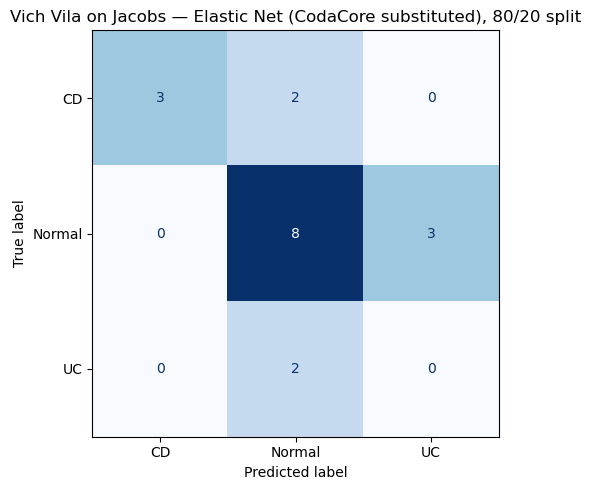


Saved Row 11. Current table:
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   

    Sensitivity  Specificity  Precision  Recall  F1_score  N_train  N_test  \
0        0.7727       0.8812     0.7791  0.7727    

In [20]:
# ----------------------------------------------------------------------------
# STEP 4b: Build covariate table (Age + Gender - Jacobs doesn't have
# Calprotectin, unlike Franzosa; adapting to what's actually available)
# ----------------------------------------------------------------------------
covariates = metadata[["Sample", "Age", "Gender", "Study.Group"]].copy()

# Encode Gender numerically (0/1) since it's categorical
covariates["Gender_encoded"] = covariates["Gender"].astype("category").cat.codes

# Median-impute Age if any missing
covariates["Age"] = covariates["Age"].fillna(covariates["Age"].median())

print(f"Missing values in covariates after imputation:\n{covariates.isna().sum()}")
print(f"\nGender categories found: {covariates['Gender'].unique()}")

# ----------------------------------------------------------------------------
# STEP 5: Encode labels
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(covariates["Study.Group"])
class_names = label_encoder.classes_
print(f"\nClasses: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 6: OUR OWN 80/20 stratified split
# ----------------------------------------------------------------------------
X_combined = pd.concat([X_imputed.reset_index(drop=True),
                         covariates[["Age", "Gender_encoded"]].reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 7: Elastic Net classifier (substituting for CodaCore)
# ----------------------------------------------------------------------------
model = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ----------------------------------------------------------------------------
# STEP 8: Metrics
# ----------------------------------------------------------------------------
auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))
sens_per_class, spec_per_class = [], []
for i in range(len(class_names)):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
    sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

sensitivity = np.mean(sens_per_class)
specificity = np.mean(spec_per_class)

print("\n" + "=" * 70)
print("TASK 3 RESULT — Vich Vila on Jacobs (CodaCore substituted, 80/20 split)")
print("=" * 70)
print(f"AUC:         {auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 score:    {f1:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 9: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Vich Vila on Jacobs — Elastic Net (CodaCore substituted), 80/20 split")
plt.tight_layout()
plt.savefig("task3_row11_vichvila_jacobs_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 10: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": "Vich Vila (ElasticNet, CodaCore substituted)",
    "Dataset": "Jacobs",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_combined.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 11. Current table:")
print(task3_results)

In [21]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 4, ROW 3: Vich Vila on MetAML (CodaCore substituted)
# STEP 1-3: Load data, apply filter + imputation
# ============================================================================

species = pd.read_csv("metaml_species_abundance.csv")
metadata = pd.read_csv("metaml_metadata_final.csv")

sample_col = species.columns[0]
feature_cols = [c for c in species.columns if c != sample_col]
print(f"Loaded MetAML: {species.shape[0]} samples, {len(feature_cols)} raw species features")
print("Metadata columns:", list(metadata.columns))

X_raw = species[feature_cols]

presence_frac = X_raw.notna().sum(axis=0) / X_raw.shape[0]
kept_features = presence_frac[presence_frac >= 0.70].index.tolist()
print(f"After 70% presence filter: {len(kept_features)} features")

X_filtered = X_raw[kept_features]

X_imputed = X_filtered.copy()
for col in X_imputed.columns:
    if X_imputed[col].isna().any():
        min_val = X_imputed[col].min(skipna=True)
        X_imputed[col] = X_imputed[col].fillna(min_val / 2)

print(f"Any remaining NAs after imputation? {X_imputed.isna().sum().sum()}")

possible_covariate_cols = [c for c in metadata.columns if c.lower() in
                            ["age", "calprotectin", "fecal.calprotectin", "bmi", "sex", "gender"]]
print(f"\nPossible covariate columns found: {possible_covariate_cols}")

Loaded MetAML: 445 samples, 3302 raw species features
Metadata columns: ['dataset_name', 'Sample', 'subjectID', 'bodysite', 'disease', 'age', 'gender', 'country', 'sequencing_technology', 'pubmedid', 'Study.Group']
After 70% presence filter: 3302 features
Any remaining NAs after imputation? 0

Possible covariate columns found: ['age', 'gender']


Missing values in covariates after imputation:
Sample            0
age               0
gender            0
Study.Group       0
gender_encoded    0
dtype: int64

Gender categories found: ['female' 'male']

Classes: ['CD', 'Control', 'UC']
Train: 356 samples | Test: 89 samples

TASK 3 RESULT — Vich Vila on MetAML (CodaCore substituted, 80/20 split)
AUC:         0.9085
Sensitivity: 0.7012
Specificity: 0.9014
Precision:   0.7675
Recall:      0.7012
F1 score:    0.7215

Full classification report:
              precision    recall  f1-score   support

          CD       0.67      0.40      0.50         5
     Control       0.92      0.87      0.90        54
          UC       0.71      0.83      0.77        30

    accuracy                           0.83        89
   macro avg       0.77      0.70      0.72        89
weighted avg       0.84      0.83      0.83        89



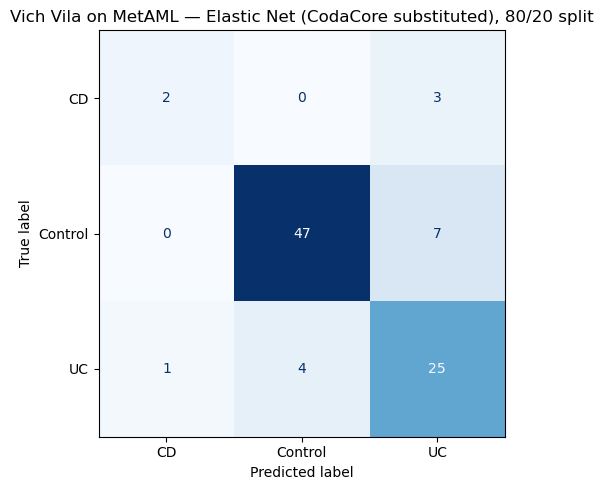


Saved Row 12. Current table:
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   
11  Vich Vila (ElasticNet, CodaCore substituted)    MetAML  0.9085   

    Sensitivity  Specificity  Precision  Recall  F1_score  

In [23]:
# ----------------------------------------------------------------------------
# STEP 4 (fixed): Build covariate table - age needs numeric conversion first,
# since MetAML stores it as text with 'na' string values mixed in
# ----------------------------------------------------------------------------
covariates = metadata[["Sample", "age", "gender", "Study.Group"]].copy()

# Convert age to actual numbers - anything that can't convert (like 'na') becomes NaN
covariates["age"] = pd.to_numeric(covariates["age"], errors="coerce")

covariates["gender_encoded"] = covariates["gender"].astype("category").cat.codes
covariates["age"] = covariates["age"].fillna(covariates["age"].median())

print(f"Missing values in covariates after imputation:\n{covariates.isna().sum()}")
print(f"\nGender categories found: {covariates['gender'].unique()}")
# ----------------------------------------------------------------------------
# STEP 5: Encode labels
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(covariates["Study.Group"])
class_names = label_encoder.classes_
print(f"\nClasses: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 6: OUR OWN 80/20 stratified split
# ----------------------------------------------------------------------------
X_combined = pd.concat([X_imputed.reset_index(drop=True),
                         covariates[["age", "gender_encoded"]].reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 7: Elastic Net classifier (substituting for CodaCore)
# ----------------------------------------------------------------------------
model = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23)
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ----------------------------------------------------------------------------
# STEP 8: Metrics
# ----------------------------------------------------------------------------
auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
f1 = f1_score(y_test, y_pred, average="macro")
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=range(len(class_names)))
sens_per_class, spec_per_class = [], []
for i in range(len(class_names)):
    tp = cm[i, i]; fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
    sens_per_class.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_per_class.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

sensitivity = np.mean(sens_per_class)
specificity = np.mean(spec_per_class)

print("\n" + "=" * 70)
print("TASK 3 RESULT — Vich Vila on MetAML (CodaCore substituted, 80/20 split)")
print("=" * 70)
print(f"AUC:         {auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 score:    {f1:.4f}")
print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 9: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Vich Vila on MetAML — Elastic Net (CodaCore substituted), 80/20 split")
plt.tight_layout()
plt.savefig("task3_row12_vichvila_metaml_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 10: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": "Vich Vila (ElasticNet, CodaCore substituted)",
    "Dataset": "MetAML",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_combined.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 12. Current table:")
print(task3_results)

## Task 3 — Row 13: MetAML's own methodology on Franzosa

MetAML's own approach (as reproduced earlier: relative-abundance
normalization, RF/SVM/LASSO/Elastic Net classifiers compared), applied to
Franzosa's metabolite data, with our own 80/20 stratified split for
consistency with the rest of Task 3.

Loaded Franzosa: 220 samples, 8848 raw features
Classes: ['CD', 'Control', 'UC']
Train: 176 samples | Test: 44 samples

TASK 3 RESULT — MetAML's own methodology on Franzosa (80/20 split)
RandomForest — AUC: 0.8895 | Sens: 0.7098 | Spec: 0.8468 | F1: 0.7040
SVM          — AUC: 0.8710 | Sens: 0.7542 | Spec: 0.8697 | F1: 0.7549
LASSO        — AUC: 0.5000 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.1935 *** has a zero-recall class ***
ElasticNet   — AUC: 0.7378 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.1935 *** has a zero-recall class ***

Best classifier: RandomForest
              precision    recall  f1-score   support

          CD       0.70      0.78      0.74        18
     Control       0.75      0.82      0.78        11
          UC       0.67      0.53      0.59        15

    accuracy                           0.70        44
   macro avg       0.71      0.71      0.70        44
weighted avg       0.70      0.70      0.70        44



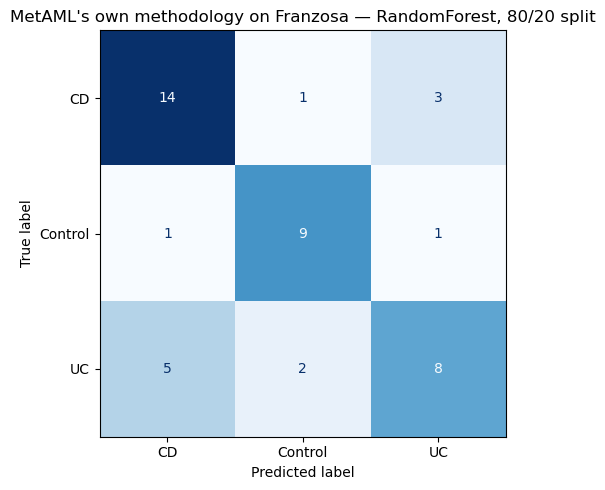


Saved Row 13. Current table:
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   
11  Vich Vila (ElasticNet, CodaCore substituted)    MetAML  0.9085   
12                   MetAML's own (RandomForest)  Franzosa  

In [25]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 5, ROW 1: MetAML's own methodology on Franzosa
# Relative-abundance normalization, then RF/SVM/LASSO/ElasticNet compared,
# best reported (matching their own multi-classifier comparison approach).
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, precision_score,
    recall_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# STEP 1: Load Franzosa fresh
# ----------------------------------------------------------------------------
mtb = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/mtb.tsv", sep="\t")
metadata = pd.read_csv("FRANZOSA_IBD_2019/FRANZOSA_IBD_2019/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Franzosa: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

X_raw = mtb[feature_cols].fillna(0)

# ----------------------------------------------------------------------------
# STEP 2: Relative abundance normalization (MetAML's own approach - each
# sample's features sum to 1, i.e. relative abundance / compositional form)
# ----------------------------------------------------------------------------
X_relabund = X_raw.div(X_raw.sum(axis=1) + 1e-10, axis=0)

# ----------------------------------------------------------------------------
# STEP 3: Encode labels
# ----------------------------------------------------------------------------
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata["Study.Group"])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

# ----------------------------------------------------------------------------
# STEP 4: OUR OWN 80/20 stratified split
# ----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_relabund, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# ----------------------------------------------------------------------------
# STEP 5: Train all four classifiers (matching MetAML's own comparison)
# ----------------------------------------------------------------------------
results = {}

rf = RandomForestClassifier(n_estimators=300, random_state=23)
rf.fit(X_train, y_train)
results["RandomForest"] = (rf.predict(X_test), rf.predict_proba(X_test))

svm = SVC(probability=True, random_state=23)
svm.fit(X_train, y_train)
results["SVM"] = (svm.predict(X_test), svm.predict_proba(X_test))

lasso = OneVsRestClassifier(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, random_state=23))
lasso.fit(X_train, y_train)
results["LASSO"] = (lasso.predict(X_test), lasso.predict_proba(X_test))

enet = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23))
enet.fit(X_train, y_train)
results["ElasticNet"] = (enet.predict(X_test), enet.predict_proba(X_test))

# ----------------------------------------------------------------------------
# STEP 6: Metrics, corrected selection (AUC among no-zero-recall
# classifiers, F1 fallback if all have a zero-recall class)
# ----------------------------------------------------------------------------
def compute_metrics(y_test, y_pred, y_proba, class_names):
    n_classes = len(class_names)
    if n_classes == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
    sens, spec = [], []
    for i in range(n_classes):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    has_zero_recall = any(s == 0 for s in sens)
    return auc, np.mean(sens), np.mean(spec), precision, recall, f1, cm, has_zero_recall

print("\n" + "=" * 70)
print("TASK 3 RESULT — MetAML's own methodology on Franzosa (80/20 split)")
print("=" * 70)

all_results = {}
for name, (y_pred, y_proba) in results.items():
    auc, sens, spec, prec, rec, f1, cm, zero_recall = compute_metrics(
        y_test, y_pred, y_proba, class_names)
    all_results[name] = (auc, sens, spec, prec, rec, f1, cm, y_pred, zero_recall)
    flag = " *** has a zero-recall class ***" if zero_recall else ""
    print(f"{name:12s} — AUC: {auc:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | F1: {f1:.4f}{flag}")

clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])
else:
    best_name = max(all_results, key=lambda k: all_results[k][5])

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier: {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# ----------------------------------------------------------------------------
# STEP 7: Confusion matrix plot
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"MetAML's own methodology on Franzosa — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row13_metaml_own_franzosa_confusion.png", dpi=150)
plt.show()

# ----------------------------------------------------------------------------
# STEP 8: Save row
# ----------------------------------------------------------------------------
new_row = pd.DataFrame([{
    "Methodology": f"MetAML's own ({best_name})",
    "Dataset": "Franzosa",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_relabund.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 13. Current table:")
print(task3_results)

In [26]:
task3_results = pd.read_csv("task3_results_table.csv")
print(f"Before cleanup: {len(task3_results)} rows")

task3_results = task3_results.drop_duplicates(subset=["Methodology", "Dataset"], keep="first")
task3_results = task3_results.reset_index(drop=True)

print(f"After cleanup: {len(task3_results)} rows")
task3_results.to_csv("task3_results_table.csv", index=False)
print(task3_results)

Before cleanup: 14 rows
After cleanup: 13 rows
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   
11  Vich Vila (ElasticNet, CodaCore substituted)    MetAML  0.9085   
12                   MetAML's own (RandomFo

Loaded Jacobs: 90 samples, 4626 raw features
Classes: ['CD', 'Normal', 'UC']
Train: 72 samples | Test: 18 samples

TASK 3 RESULT — MetAML's own methodology on Jacobs (80/20 split)
RandomForest — AUC: 0.7486 | Sens: 0.4000 | Spec: 0.7143 | F1: 0.3730 *** has a zero-recall class ***
SVM          — AUC: 0.7269 | Sens: 0.5333 | Spec: 0.8095 | F1: 0.5321 *** has a zero-recall class ***
LASSO        — AUC: 0.5000 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.2529 *** has a zero-recall class ***
ElasticNet   — AUC: 0.5000 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.2529 *** has a zero-recall class ***

Best classifier: SVM
              precision    recall  f1-score   support

          CD       1.00      0.60      0.75         5
      Normal       0.73      1.00      0.85        11
          UC       0.00      0.00      0.00         2

    accuracy                           0.78        18
   macro avg       0.58      0.53      0.53        18
weighted avg       0.73      0.78      0.73        18



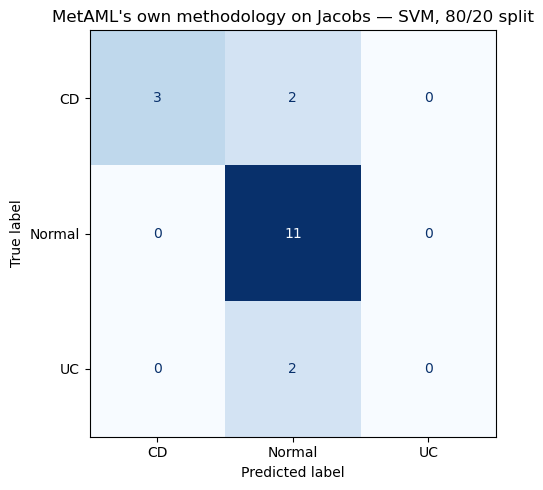


Saved Row 14. Current table:
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   
11  Vich Vila (ElasticNet, CodaCore substituted)    MetAML  0.9085   
12                   MetAML's own (RandomForest)  Franzosa  

In [27]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 5, ROW 2: MetAML's own methodology on Jacobs
# ============================================================================

jacobs_folder = "borenstein-lab microbiome-metabolome-curated-data main data-processed_data_JACOBS_IBD_FAMILIES_2016"

mtb = pd.read_csv(f"{jacobs_folder}/mtb.tsv", sep="\t")
metadata = pd.read_csv(f"{jacobs_folder}/metadata.tsv", sep="\t")
feature_cols = [c for c in mtb.columns if c != "Sample"]
print(f"Loaded Jacobs: {mtb.shape[0]} samples, {len(feature_cols)} raw features")

X_raw = mtb[feature_cols].fillna(0)

X_relabund = X_raw.div(X_raw.sum(axis=1) + 1e-10, axis=0)

label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_relabund, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

results = {}

rf = RandomForestClassifier(n_estimators=300, random_state=23)
rf.fit(X_train, y_train)
results["RandomForest"] = (rf.predict(X_test), rf.predict_proba(X_test))

svm = SVC(probability=True, random_state=23)
svm.fit(X_train, y_train)
results["SVM"] = (svm.predict(X_test), svm.predict_proba(X_test))

lasso = OneVsRestClassifier(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, random_state=23))
lasso.fit(X_train, y_train)
results["LASSO"] = (lasso.predict(X_test), lasso.predict_proba(X_test))

enet = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23))
enet.fit(X_train, y_train)
results["ElasticNet"] = (enet.predict(X_test), enet.predict_proba(X_test))

print("\n" + "=" * 70)
print("TASK 3 RESULT — MetAML's own methodology on Jacobs (80/20 split)")
print("=" * 70)

all_results = {}
for name, (y_pred, y_proba) in results.items():
    auc, sens, spec, prec, rec, f1, cm, zero_recall = compute_metrics(
        y_test, y_pred, y_proba, class_names)
    all_results[name] = (auc, sens, spec, prec, rec, f1, cm, y_pred, zero_recall)
    flag = " *** has a zero-recall class ***" if zero_recall else ""
    print(f"{name:12s} — AUC: {auc:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | F1: {f1:.4f}{flag}")

clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])
else:
    best_name = max(all_results, key=lambda k: all_results[k][5])

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier: {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"MetAML's own methodology on Jacobs — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row14_metaml_own_jacobs_confusion.png", dpi=150)
plt.show()

new_row = pd.DataFrame([{
    "Methodology": f"MetAML's own ({best_name})",
    "Dataset": "Jacobs",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_relabund.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 14. Current table:")
print(task3_results)

Loaded MetAML: 445 samples, 3302 raw features
Classes: ['CD', 'Control', 'UC']
Train: 356 samples | Test: 89 samples

TASK 3 RESULT — MetAML's own methodology on MetAML (80/20 split)
RandomForest — AUC: 0.9573 | Sens: 0.6988 | Spec: 0.8972 | F1: 0.7327
SVM          — AUC: 0.8895 | Sens: 0.4864 | Spec: 0.8081 | F1: 0.4790 *** has a zero-recall class ***
LASSO        — AUC: 0.5000 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.2517 *** has a zero-recall class ***
ElasticNet   — AUC: 0.5846 | Sens: 0.3333 | Spec: 0.6667 | F1: 0.2517 *** has a zero-recall class ***

Best classifier: RandomForest
              precision    recall  f1-score   support

          CD       0.67      0.40      0.50         5
     Control       0.87      0.96      0.91        54
          UC       0.85      0.73      0.79        30

    accuracy                           0.85        89
   macro avg       0.79      0.70      0.73        89
weighted avg       0.85      0.85      0.85        89



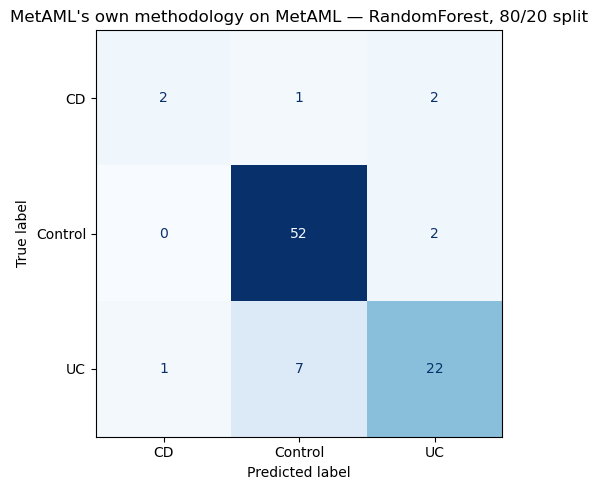


Saved Row 15 — TASK 3 TABLE COMPLETE. Final table:
                                     Methodology   Dataset     AUC  \
0                              Acharjee/Hodgkiss  Franzosa  0.8986   
1                              Acharjee/Hodgkiss    Jacobs  0.9015   
2                              Acharjee/Hodgkiss    MetAML  0.9383   
3                               IBDpred (GLMnet)  Franzosa  0.8189   
4                               IBDpred (GLMnet)    Jacobs  0.8317   
5                         IBDpred (RandomForest)    MetAML  0.9590   
6                         SIAMCAT (RandomForest)  Franzosa  0.8658   
7                         SIAMCAT (RandomForest)    Jacobs  0.7011   
8                         SIAMCAT (RandomForest)    MetAML  0.9379   
9   Vich Vila (ElasticNet, CodaCore substituted)  Franzosa  0.8265   
10  Vich Vila (ElasticNet, CodaCore substituted)    Jacobs  0.6891   
11  Vich Vila (ElasticNet, CodaCore substituted)    MetAML  0.9085   
12                   MetAML's own (Ran

In [28]:
# ============================================================================
# TASK 3 - MAIN THESIS TABLE
# METHODOLOGY 5, ROW 3 (FINAL ROW): MetAML's own methodology on MetAML
# ============================================================================

species = pd.read_csv("metaml_species_abundance.csv")
metadata = pd.read_csv("metaml_metadata_final.csv")

sample_col = species.columns[0]
feature_cols = [c for c in species.columns if c != sample_col]
print(f"Loaded MetAML: {species.shape[0]} samples, {len(feature_cols)} raw features")

X_raw = species[feature_cols].fillna(0)

X_relabund = X_raw.div(X_raw.sum(axis=1) + 1e-10, axis=0)

label_col = "Study.Group"
label_encoder = LabelEncoder()
y_full = label_encoder.fit_transform(metadata[label_col])
class_names = label_encoder.classes_
print(f"Classes: {list(class_names)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_relabund, y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=23
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

results = {}

rf = RandomForestClassifier(n_estimators=300, random_state=23)
rf.fit(X_train, y_train)
results["RandomForest"] = (rf.predict(X_test), rf.predict_proba(X_test))

svm = SVC(probability=True, random_state=23)
svm.fit(X_train, y_train)
results["SVM"] = (svm.predict(X_test), svm.predict_proba(X_test))

lasso = OneVsRestClassifier(
    LogisticRegression(penalty="l1", solver="liblinear", max_iter=5000, random_state=23))
lasso.fit(X_train, y_train)
results["LASSO"] = (lasso.predict(X_test), lasso.predict_proba(X_test))

enet = OneVsRestClassifier(
    LogisticRegression(penalty="elasticnet", l1_ratio=0.5, solver="saga",
                        max_iter=5000, random_state=23))
enet.fit(X_train, y_train)
results["ElasticNet"] = (enet.predict(X_test), enet.predict_proba(X_test))

print("\n" + "=" * 70)
print("TASK 3 RESULT — MetAML's own methodology on MetAML (80/20 split)")
print("=" * 70)

all_results = {}
for name, (y_pred, y_proba) in results.items():
    auc, sens, spec, prec, rec, f1, cm, zero_recall = compute_metrics(
        y_test, y_pred, y_proba, class_names)
    all_results[name] = (auc, sens, spec, prec, rec, f1, cm, y_pred, zero_recall)
    flag = " *** has a zero-recall class ***" if zero_recall else ""
    print(f"{name:12s} — AUC: {auc:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f} | F1: {f1:.4f}{flag}")

clean_candidates = {k: v for k, v in all_results.items() if not v[8]}
if clean_candidates:
    best_name = max(clean_candidates, key=lambda k: clean_candidates[k][0])
else:
    best_name = max(all_results, key=lambda k: all_results[k][5])

auc, sensitivity, specificity, precision, recall, f1, cm, y_pred, _ = all_results[best_name]

print(f"\nBest classifier: {best_name}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"MetAML's own methodology on MetAML — {best_name}, 80/20 split")
plt.tight_layout()
plt.savefig("task3_row15_metaml_own_metaml_confusion.png", dpi=150)
plt.show()

new_row = pd.DataFrame([{
    "Methodology": f"MetAML's own ({best_name})",
    "Dataset": "MetAML",
    "AUC": round(auc, 4),
    "Sensitivity": round(sensitivity, 4),
    "Specificity": round(specificity, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1_score": round(f1, 4),
    "N_train": X_train.shape[0],
    "N_test": X_test.shape[0],
    "N_features_selected": X_relabund.shape[1],
}])

existing = pd.read_csv("task3_results_table.csv")
task3_results = pd.concat([existing, new_row], ignore_index=True)
task3_results.to_csv("task3_results_table.csv", index=False)
print("\nSaved Row 15 — TASK 3 TABLE COMPLETE. Final table:")
print(task3_results)